# **Siti Naia Hesti Rachmawati | 24083010047**

# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import BayesianGaussianMixture
import hdbscan
import warnings
warnings.filterwarnings('ignore')

# **Load Data**

In [ ]:
url = "https://raw.githubusercontent.com/naiarch/clustering-ship-performance-dataset/main/Ship_Performance_Dataset.csv"
df = pd.read_csv(url)
df

,Date,Ship_Type,Route_Type,Engine_Type,Maintenance_Status,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Weather_Condition,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
0,2023-06-04,Container Ship,NaN,Heavy Fuel Oil (HFO),Critical,12.597558,2062.983982,1030.943616,14.132284,Moderate,1959.017882,483832.354540,292183.273104,25.867077,1.455179,1.415653,1,93.769249
1,2023-06-11,Fish Carrier,Short-haul,Steam Turbine,Good,10.387580,1796.057415,1060.486382,14.653083,Rough,162.394712,483388.000509,883765.787360,63.248196,0.290361,0.885648,6,93.895372
2,2023-06-18,Container Ship,Long-haul,Diesel,Fair,20.749747,1648.556685,658.874144,7.199261,Moderate,178.040917,448543.404044,394018.746904,49.418150,0.499595,1.405813,9,96.218244
3,2023-06-25,Bulk Carrier,Transoceanic,Steam Turbine,Fair,21.055102,915.261795,1126.822519,11.789063,Moderate,1737.385346,261349.605449,87551.375175,22.409110,0.702906,1.370704,1,66.193698
4,2023-07-02,Fish Carrier,Transoceanic,Diesel,Fair,13.742777,1089.721803,1445.281159,9.727833,Moderate,260.595103,287718.375160,676121.459632,64.158231,1.331343,0.583383,8,80.008581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2731,2024-06-02,Tanker,Short-haul,Heavy Fuel Oil (HFO),Good,11.607997,2918.395972,239.990359,13.700906,Moderate,318.111891,237975.067292,731584.322921,47.152337,1.000265,1.284895,3,74.813114
2732,2024-06-09,Bulk Carrier,Short-haul,Heavy Fuel Oil (HFO),Good,13.852798,2161.282358,831.355653,14.612775,NaN,218.309002,21029.021721,374365.370930,64.325916,0.653474,0.891085,2,84.595155
2733,2024-06-16,Container Ship,Short-haul,Steam Turbine,Critical,16.813713,1343.608006,1376.460622,9.306518,NaN,1630.646419,78883.312529,234120.365052,53.551090,0.594169,0.725404,6,80.975269
2734,2024-06-23,Tanker,Transoceanic,Heavy Fuel Oil (HFO),Good,23.132643,2028.143572,619.236340,6.623856,Moderate,153.441965,25241.550250,799713.737211,14.335517,0.895670,0.902960,2,92.853622


# **Informasi Data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2736 entries, 0 to 2735
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     2736 non-null   object 
 1   Ship_Type                2600 non-null   object 
 2   Route_Type               2600 non-null   object 
 3   Engine_Type              2600 non-null   object 
 4   Maintenance_Status       2600 non-null   object 
 5   Speed_Over_Ground_knots  2736 non-null   float64
 6   Engine_Power_kW          2736 non-null   float64
 7   Distance_Traveled_nm     2736 non-null   float64
 8   Draft_meters             2736 non-null   float64
 9   Weather_Condition        2600 non-null   object 
 10  Cargo_Weight_tons        2736 non-null   float64
 11  Operational_Cost_USD     2736 non-null   float64
 12  Revenue_per_Voyage_USD   2736 non-null   float64
 13  Turnaround_Time_hours    2736 non-null   float64
 14  Efficiency_nm_per_kWh   

> Dataset yang digunakan pada analisis clustering ini berisi 2.736 baris data dengan 18 kolom yang merepresentasikan karakteristik performa kapal. Berdasarkan tampilan awal data, variabel yang tersedia mencakup atribut identitas dan operasional kapal, seperti Date, Ship_Type, Route_Type, Engine_Type, Maintenance_Status, Weather_Condition, hingga variabel numerik seperti Speed_Over_Ground_knots, Engine_Power_kW, Distance_Traveled_nm, Cargo_Weight_tons, Operational_Cost_USD, Revenue_per_Voyage_USD, dan beberapa indikator efisiensi serta aktivitas pelayaran. Keberagaman atribut tersebut menunjukkan bahwa dataset memiliki informasi yang cukup lengkap untuk membentuk pengelompokan berdasarkan pola performa operasional kapal.

> Berdasarkan hasil info(), terlihat bahwa tidak semua kolom memiliki jumlah data yang lengkap. Beberapa atribut kategorikal, yaitu Ship_Type, Route_Type, Engine_Type, Maintenance_Status, dan Weather_Condition, hanya memiliki 2.600 data non-null. Artinya, terdapat 136 data hilang pada masing-masing kolom tersebut. Sementara itu, seluruh variabel numerik memiliki data lengkap sebanyak 2.736 entri. Kondisi ini menunjukkan bahwa data numerik relatif siap digunakan, sedangkan kolom kategorikal memerlukan penanganan missing value sebelum proses clustering dilakukan.

> Dari sisi tipe data, dataset terdiri atas 11 variabel bertipe float, 1 variabel bertipe int, dan 6 variabel bertipe object, sedangkan Date masih terbaca sebagai object. Struktur data ini sudah cukup sesuai untuk analisis clustering. Namun, karena metode clustering lebih optimal digunakan pada data numerik, maka atribut kategorikal perlu diubah ke bentuk numerik melalui proses encoding atau hanya digunakan sebagai informasi pendukung dalam interpretasi hasil cluster.

In [ ]:
# @title statistik deskriptif
df.describe()

,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
count,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000,2736.000000
mean,17.602863,1757.610939,1036.406203,9.929103,1032.573264,255143.344488,521362.062011,41.747536,0.798656,1.003816,4.914839,75.219222
std,4.311979,717.002777,568.632080,2.876423,558.697499,140890.482189,271211.625499,17.633130,0.403590,0.288251,2.597647,14.510168
min,10.009756,501.025220,50.433150,5.001947,50.229624,10092.306318,50351.814447,12.019909,0.100211,0.500004,1.000000,50.012005
25%,13.928452,1148.104914,548.511573,7.437485,553.983629,131293.378767,290346.388017,26.173537,0.463592,0.758033,3.000000,62.703724
50%,17.713757,1757.494344,1037.816060,9.918965,1043.207497,257157.653226,520176.931762,41.585188,0.789877,1.009009,5.000000,75.504709
75%,21.284785,2382.594292,1540.934161,12.413149,1527.722391,381796.930499,750072.791216,57.363922,1.147426,1.252808,7.000000,87.721205
max,24.997043,2998.734329,1998.337057,14.992947,1999.126697,499734.867868,999916.696140,71.972415,1.499259,1.499224,9.000000,99.999643


> Berdasarkan hasil statistik deskriptif, seluruh variabel numerik memiliki jumlah data sebanyak 2.736 observasi, sehingga tidak terdapat missing value pada atribut numerik. Hal ini menunjukkan bahwa data numerik sudah cukup lengkap dan siap digunakan dalam proses clustering tanpa perlu penanganan data kosong tambahan pada variabel numerik.

> Variabel Speed_Over_Ground_knots memiliki rata-rata kecepatan kapal sebesar 17,60 knots dengan nilai minimum sekitar 10 knots dan maksimum hampir 25 knots. Standar deviasi sebesar 4,31 menunjukkan adanya variasi kecepatan kapal yang cukup beragam. Sementara itu, Engine_Power_kW memiliki rata-rata sebesar 1757,61 kW, dengan rentang nilai yang cukup jauh antara 501 kW hingga hampir 3000 kW. Kondisi ini mengindikasikan bahwa dataset mencakup kapal dengan kapasitas mesin rendah hingga tinggi.

> Pada variabel perjalanan, Distance_Traveled_nm memiliki rata-rata jarak tempuh sekitar 1036 nautical miles, dengan nilai minimum sekitar 50 nm dan maksimum hampir 2000 nm. Hal ini menunjukkan adanya variasi rute pelayaran, mulai dari perjalanan pendek hingga perjalanan jarak jauh. Selain itu, Draft_meters memiliki rata-rata sekitar 9,93 meter, yang menggambarkan variasi kedalaman kapal saat beroperasi.

> Variabel terkait muatan dan biaya juga menunjukkan persebaran yang cukup luas. Cargo_Weight_tons memiliki rata-rata sekitar 1032 ton, dengan nilai maksimum hampir 2000 ton. Sementara itu, Operational_Cost_USD memiliki rata-rata biaya operasional sebesar 255 ribu USD, sedangkan Revenue_per_Voyage_USD memiliki rata-rata pendapatan sekitar 521 ribu USD. Perbedaan rentang nilai pada kedua variabel tersebut menunjukkan adanya variasi efisiensi dan profitabilitas antar kapal maupun antar perjalanan.

> Pada aspek efisiensi operasional, variabel Efficiency_nm_per_kWh memiliki rata-rata sebesar 0,79, sedangkan Turnaround_Time_hours memiliki rata-rata waktu putar balik sekitar 41,75 jam. Nilai standar deviasi yang cukup besar pada kedua variabel menunjukkan bahwa performa operasional kapal cukup bervariasi. Selain itu, Weekly_Voyage_Count memiliki rata-rata sekitar 5 perjalanan per minggu, dengan rentang antara 1 hingga 9 perjalanan.

> Variabel Average_Load_Percentage memiliki rata-rata sebesar 75,22%, yang menunjukkan bahwa sebagian besar kapal beroperasi dengan tingkat muatan yang cukup tinggi. Di sisi lain, Seasonal_Impact_Score memiliki rata-rata mendekati 1, dengan rentang nilai antara 0,5 hingga 1,5, yang mengindikasikan adanya pengaruh faktor musiman terhadap aktivitas pelayaran.

> Secara keseluruhan, statistik deskriptif menunjukkan bahwa dataset memiliki variasi nilai yang cukup besar pada hampir seluruh variabel numerik. Variasi ini menjadi indikasi bahwa data memiliki karakteristik yang beragam dan berpotensi menghasilkan cluster yang berbeda berdasarkan pola performa, efisiensi operasional, kapasitas muatan, serta aktivitas pelayaran kapal.

# **Missing Value**

In [ ]:
df.isnull().sum()

,0
Date,0
Ship_Type,136
Route_Type,136
Engine_Type,136
Maintenance_Status,136
Speed_Over_Ground_knots,0
Engine_Power_kW,0
Distance_Traveled_nm,0
Draft_meters,0
Weather_Condition,136


In [ ]:
# @title penanganan missing value
# Kolom kategorikal diisi dengan modus
kolom_kategori = ['Ship_Type', 'Route_Type', 'Engine_Type',
                  'Maintenance_Status', 'Weather_Condition']

for col in kolom_kategori:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)

print('Missing value setelah ditangani:')
print(df.isnull().sum())
print(f'\nTotal missing value: {df.isnull().sum().sum()}')

Missing value setelah ditangani:
Date                       0
Ship_Type                  0
Route_Type                 0
Engine_Type                0
Maintenance_Status         0
Speed_Over_Ground_knots    0
Engine_Power_kW            0
Distance_Traveled_nm       0
Draft_meters               0
Weather_Condition          0
Cargo_Weight_tons          0
Operational_Cost_USD       0
Revenue_per_Voyage_USD     0
Turnaround_Time_hours      0
Efficiency_nm_per_kWh      0
Seasonal_Impact_Score      0
Weekly_Voyage_Count        0
Average_Load_Percentage    0
dtype: int64

Total missing value: 0


> Berdasarkan hasil pengecekan missing value, diketahui bahwa sebagian besar variabel numerik tidak memiliki data kosong. Namun, terdapat beberapa variabel kategorikal yang memiliki missing value sebanyak 136 data, yaitu pada kolom Ship_Type, Route_Type, Engine_Type, Maintenance_Status, dan Weather_Condition. Sementara itu, kolom lainnya memiliki jumlah missing value sebesar 0.

> Untuk mengatasi missing value tersebut, dilakukan penanganan dengan metode imputasi modus. Metode ini dilakukan dengan mengisi data kosong menggunakan nilai yang paling sering muncul pada masing-masing kolom kategorikal. Pendekatan ini dipilih karena data bertipe kategorikal tidak dapat diisi menggunakan rata-rata atau median seperti pada data numerik. Selain itu, penggunaan modus dinilai mampu mempertahankan pola distribusi kategori yang paling dominan dalam dataset.

> Setelah proses imputasi dilakukan, seluruh missing value berhasil ditangani dengan baik. Hal ini dapat dilihat dari hasil pengecekan ulang yang menunjukkan bahwa semua kolom memiliki jumlah missing value sebesar 0, dengan total missing value keseluruhan juga bernilai 0.

# **Data Duplikat**

In [ ]:
df.duplicated().sum()

np.int64(0)

Tidak terdapat data duplikat pada dataset Ship Performance

# **Distribusi Data**

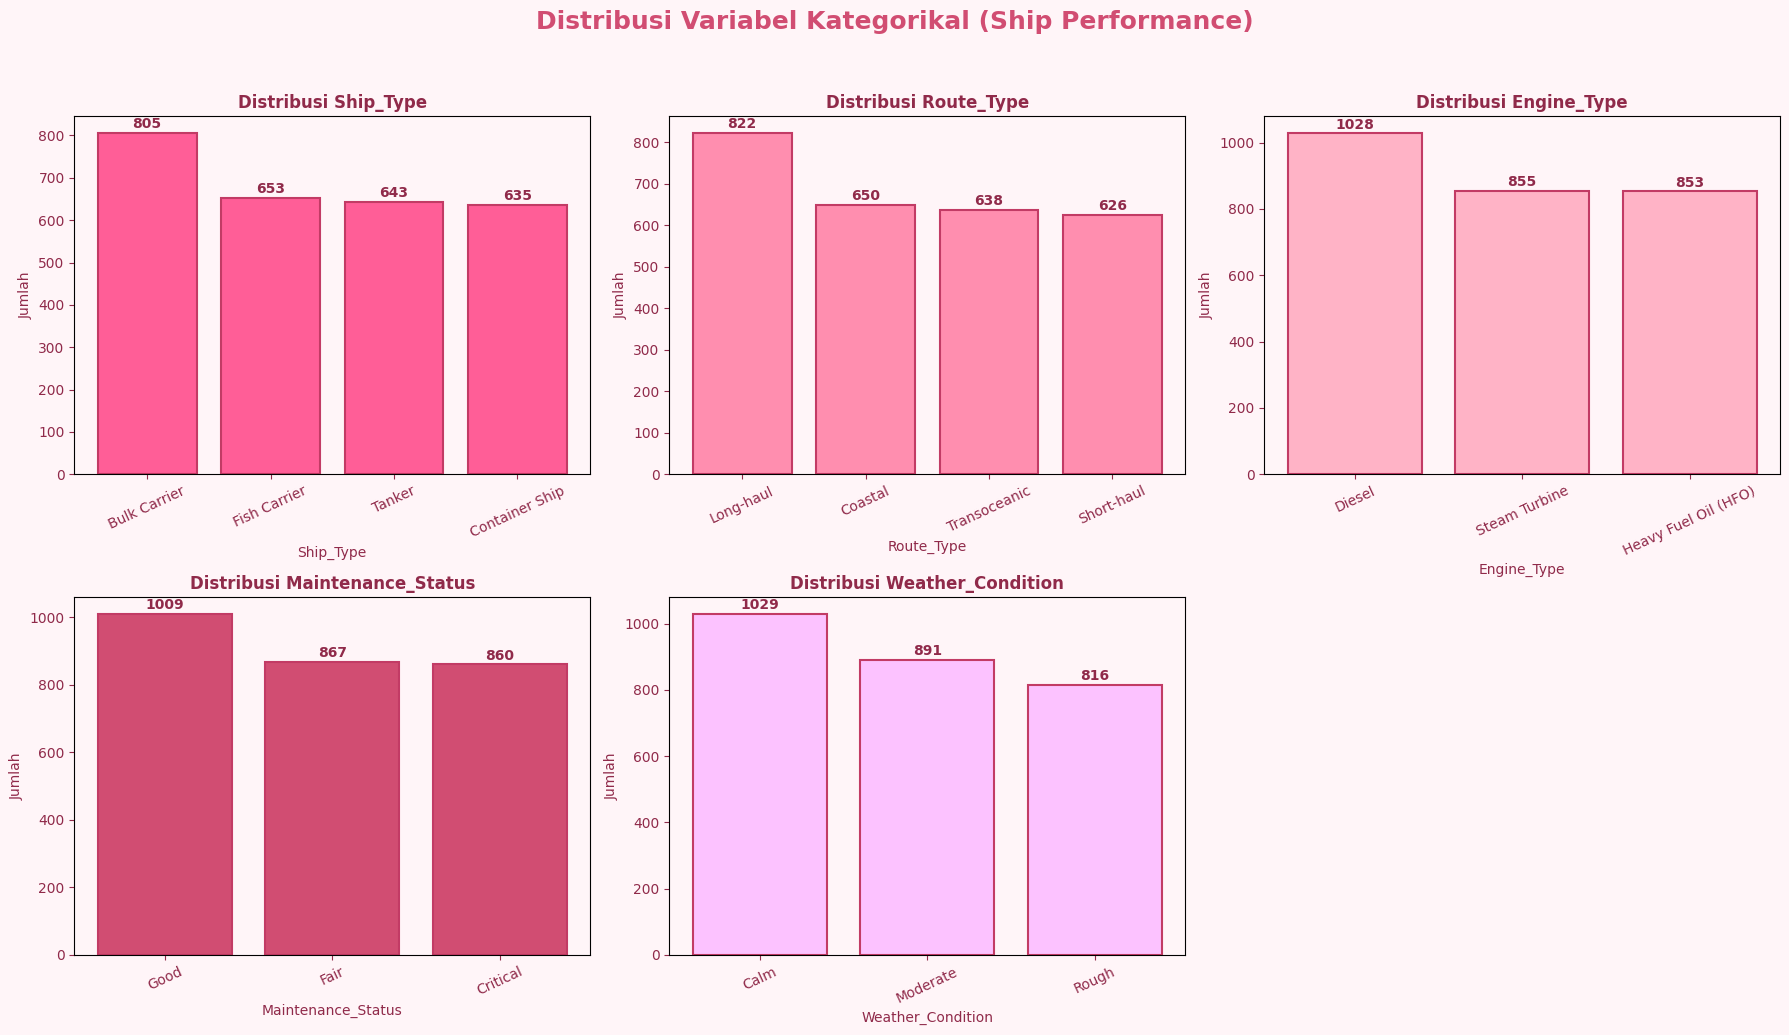

In [ ]:
# @title kolom kategorikal
kolom_kategori = ['Ship_Type', 'Route_Type', 'Engine_Type',
                  'Maintenance_Status', 'Weather_Condition']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#FFF5F8')
axes = axes.flatten()

colors = ['#FF5E97', '#FF8EAF', '#FFB3C6', '#D14D72', '#FCC2FF']

for i, col in enumerate(kolom_kategori):
    counts = df[col].value_counts()
    axes[i].set_facecolor('#FFF5F8')
    bars = axes[i].bar(counts.index, counts.values,
                       color=colors[i], edgecolor='#C23B65', linewidth=1.5)

    axes[i].set_title(f'Distribusi {col}', fontweight='bold', color='#902A4A')
    axes[i].set_xlabel(col, color='#902A4A')
    axes[i].set_ylabel('Jumlah', color='#902A4A')
    axes[i].tick_params(axis='x', rotation=25, colors='#902A4A')
    axes[i].tick_params(axis='y', colors='#902A4A')

    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 5,
                     str(val), ha='center', va='bottom',
                     fontsize=10, fontweight='bold', color='#902A4A')
axes[5].set_visible(False)

plt.suptitle('Distribusi Variabel Kategorikal (Ship Performance)',
             fontsize=18, fontweight='bold', y=1.03, color='#D14D72')

plt.tight_layout()
plt.show()

> Berdasarkan visualisasi distribusi variabel kategorikal, dapat dilihat bahwa setiap kategori memiliki jumlah data yang relatif seimbang, meskipun tetap terdapat beberapa kategori yang lebih dominan dibandingkan kategori lainnya. Kondisi ini menunjukkan bahwa dataset memiliki persebaran data yang cukup baik dan tidak terlalu terpusat pada satu kategori tertentu.

> Pada variabel Ship_Type, kategori Bulk Carrier menjadi jenis kapal dengan jumlah data terbanyak, yaitu sebanyak 805 data. Sementara itu, kategori lainnya seperti Fish Carrier, Tanker, dan Container Ship memiliki jumlah yang tidak terlalu jauh berbeda, yaitu berkisar antara 635 hingga 653 data. Hal ini menunjukkan bahwa dataset mencakup berbagai jenis kapal dengan distribusi yang cukup merata.

> Untuk variabel Route_Type, kategori Long-haul memiliki jumlah tertinggi sebanyak 822 data, sedangkan kategori Coastal, Transoceanic, dan Short-haul memiliki distribusi yang relatif seimbang. Kondisi ini menginterpretasikan bahwa aktivitas pelayaran jarak jauh sedikit lebih dominan dibandingkan jenis rute lainnya.

> Pada variabel Engine_Type, mesin Diesel menjadi tipe mesin yang paling banyak digunakan dengan jumlah 1028 data. Sementara itu, penggunaan Steam Turbine dan Heavy Fuel Oil (HFO) memiliki jumlah yang hampir sama, yaitu sekitar 850 data. Dominasi mesin diesel menunjukkan bahwa tipe mesin tersebut lebih umum digunakan dalam operasional kapal pada dataset ini.

> Variabel Maintenance_Status menunjukkan bahwa kondisi pemeliharaan Good memiliki jumlah data tertinggi sebanyak 1009 data, sedangkan kategori Fair dan Critical memiliki jumlah yang relatif seimbang. Hal ini menunjukkan bahwa sebagian besar kapal pada dataset berada dalam kondisi pemeliharaan yang baik.

> Pada variabel Weather_Condition, kondisi cuaca Calm menjadi kategori yang paling dominan dengan jumlah 1029 data, diikuti oleh Moderate sebanyak 891 data, dan Rough sebanyak 816 data. Distribusi ini menunjukkan bahwa sebagian besar aktivitas pelayaran terjadi pada kondisi cuaca yang relatif stabil.

> Visualisasi distribusi variabel kategorikal menunjukkan bahwa dataset memiliki variasi kategori yang cukup beragam dengan distribusi yang cenderung seimbang. Hal ini penting dalam analisis clustering karena keberagaman kategori dapat membantu proses pembentukan cluster yang lebih representatif terhadap karakteristik operasional kapal.

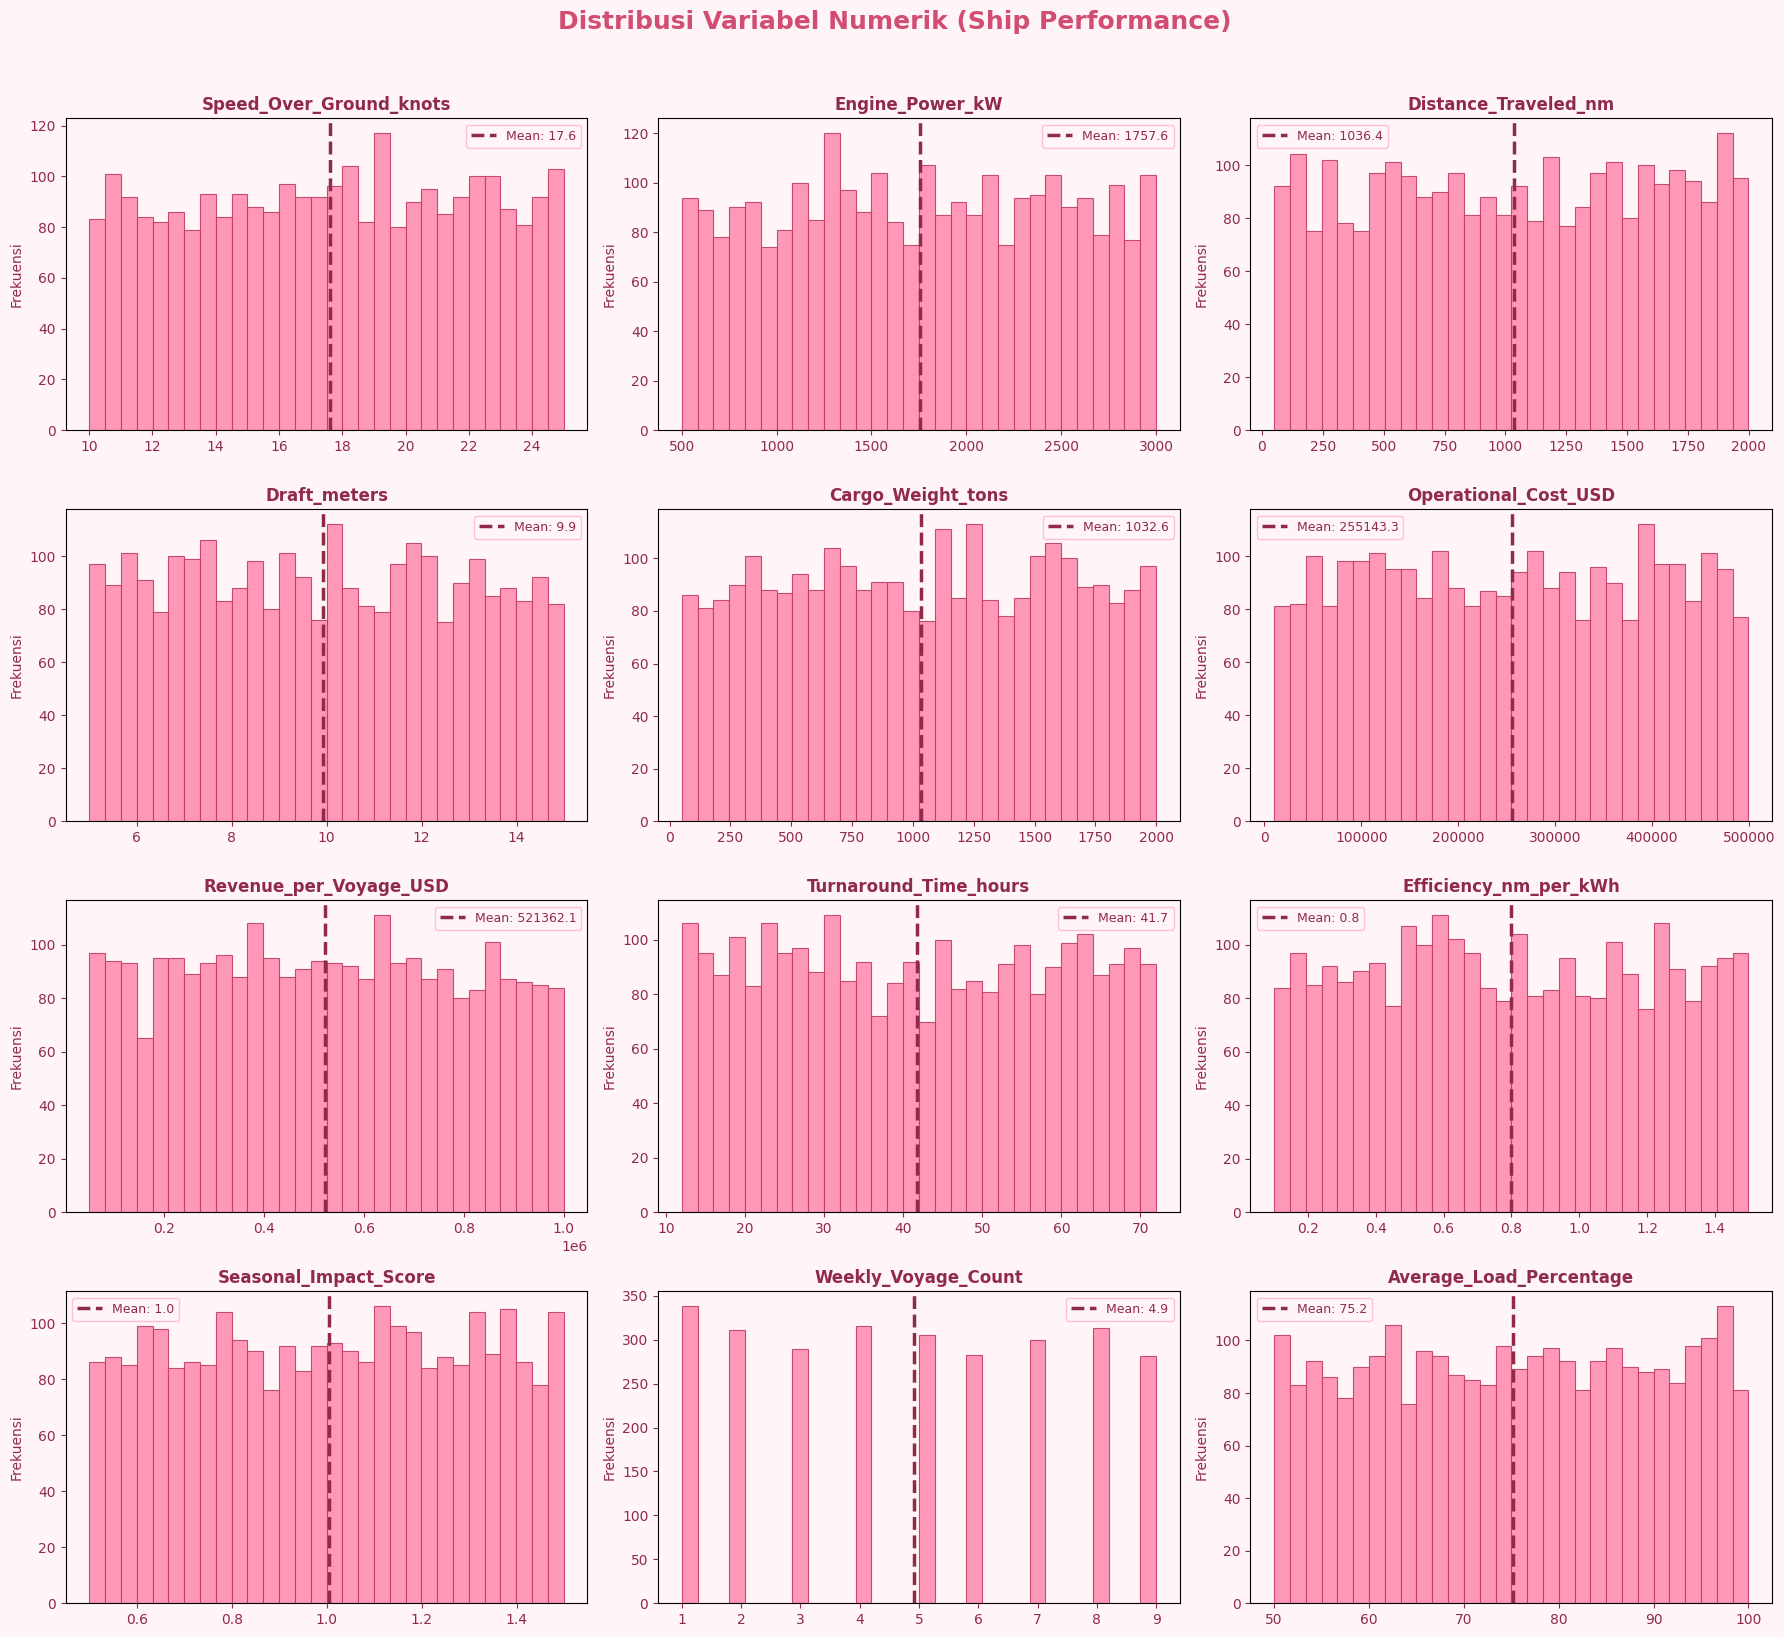

In [ ]:
# @title kolom numerik
kolom_numerik = ['Speed_Over_Ground_knots', 'Engine_Power_kW',
                 'Distance_Traveled_nm', 'Draft_meters',
                 'Cargo_Weight_tons', 'Operational_Cost_USD',
                 'Revenue_per_Voyage_USD', 'Turnaround_Time_hours',
                 'Efficiency_nm_per_kWh', 'Seasonal_Impact_Score',
                 'Weekly_Voyage_Count', 'Average_Load_Percentage']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
fig.patch.set_facecolor('#FFF5F8')
axes = axes.flatten()

for i, col in enumerate(kolom_numerik):
    axes[i].set_facecolor('#FFF5F8')
    axes[i].hist(df[col], bins=30, color='#FF8EAF',
                 edgecolor='#C23B65', linewidth=0.8, alpha=0.9)
    axes[i].axvline(df[col].mean(), color='#902A4A',
                    linestyle='--', linewidth=2.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col, fontweight='bold', color='#902A4A')
    axes[i].set_ylabel('Frekuensi', color='#902A4A')
    axes[i].tick_params(axis='x', colors='#902A4A')
    axes[i].tick_params(axis='y', colors='#902A4A')

    legend = axes[i].legend(fontsize=9, facecolor='#FFF5F8', edgecolor='#FFB3C6')
    for text in legend.get_texts():
        text.set_color('#902A4A')

plt.suptitle('Distribusi Variabel Numerik (Ship Performance)',
             fontsize=18, fontweight='bold', y=1.02, color='#D14D72')

plt.tight_layout()
plt.show()

> Berdasarkan visualisasi distribusi variabel numerik, terlihat bahwa sebagian besar variabel memiliki persebaran data yang cukup merata pada rentang nilainya masing-masing. Garis putus-putus pada setiap histogram menunjukkan nilai rata-rata dari tiap variabel, sehingga mempermudah dalam melihat pusat distribusi data.

> Variabel Speed_Over_Ground_knots menunjukkan distribusi kecepatan kapal yang relatif stabil pada rentang sekitar 10 hingga 25 knots, dengan rata-rata sebesar 17,6 knots. Persebaran data yang cukup merata menunjukkan bahwa dataset mencakup kapal dengan variasi kecepatan yang beragam tanpa adanya dominasi ekstrem pada nilai tertentu.

> Pada variabel Engine_Power_kW, distribusi daya mesin tersebar dari sekitar 500 hingga 3000 kW dengan rata-rata sebesar 1757,6 kW. Hal ini menunjukkan bahwa dataset memuat kapal dengan kapasitas mesin rendah hingga tinggi. Variabel Distance_Traveled_nm juga memiliki distribusi yang luas, mulai dari jarak tempuh pendek hingga hampir 2000 nautical miles, dengan rata-rata sekitar 1036,4 nm, yang menunjukkan variasi jenis perjalanan kapal.

> Variabel Draft_meters dan Cargo_Weight_tons menunjukkan distribusi yang cukup merata pada seluruh rentang nilai. Rata-rata draft kapal berada di sekitar 9,9 meter, sedangkan rata-rata berat muatan mencapai sekitar 1032,6 ton. Hal ini menunjukkan adanya variasi ukuran kapal dan kapasitas angkut dalam dataset.

> Pada aspek ekonomi operasional, variabel Operational_Cost_USD dan Revenue_per_Voyage_USD memiliki distribusi yang cukup luas. Rata-rata biaya operasional berada di sekitar 255 ribu USD, sedangkan rata-rata pendapatan pelayaran mencapai sekitar 521 ribu USD. Persebaran yang luas pada kedua variabel ini menunjukkan bahwa setiap perjalanan kapal memiliki karakteristik biaya dan pendapatan yang berbeda-beda.

> Variabel Turnaround_Time_hours memiliki rata-rata sekitar 41,7 jam, dengan distribusi yang cukup merata dari waktu putar balik rendah hingga tinggi. Sementara itu, Efficiency_nm_per_kWh memiliki rata-rata sekitar 0,8, yang menunjukkan tingkat efisiensi perjalanan kapal berdasarkan konsumsi energi.

> Pada variabel Seasonal_Impact_Score, distribusi data terlihat relatif seimbang di rentang 0,5 hingga 1,5 dengan rata-rata mendekati 1,0. Hal ini menunjukkan bahwa pengaruh faktor musiman terhadap performa kapal cukup bervariasi. Variabel Weekly_Voyage_Count memperlihatkan jumlah perjalanan mingguan kapal yang tersebar dari 1 hingga 9 perjalanan dengan rata-rata sekitar 4,9 perjalanan per minggu.

> Selain itu, variabel Average_Load_Percentage memiliki distribusi yang cukup merata dengan rata-rata sebesar 75,2%, yang menunjukkan bahwa sebagian besar kapal beroperasi dengan tingkat muatan yang cukup tinggi.

> Visualisasi histogram menunjukkan bahwa mayoritas variabel numerik memiliki distribusi yang cukup tersebar dan tidak terlalu terpusat pada satu nilai tertentu. Variasi data yang cukup besar ini menjadi indikator bahwa dataset memiliki karakteristik yang beragam, sehingga berpotensi menghasilkan cluster yang lebih jelas dan representatif dalam proses analisis clustering.

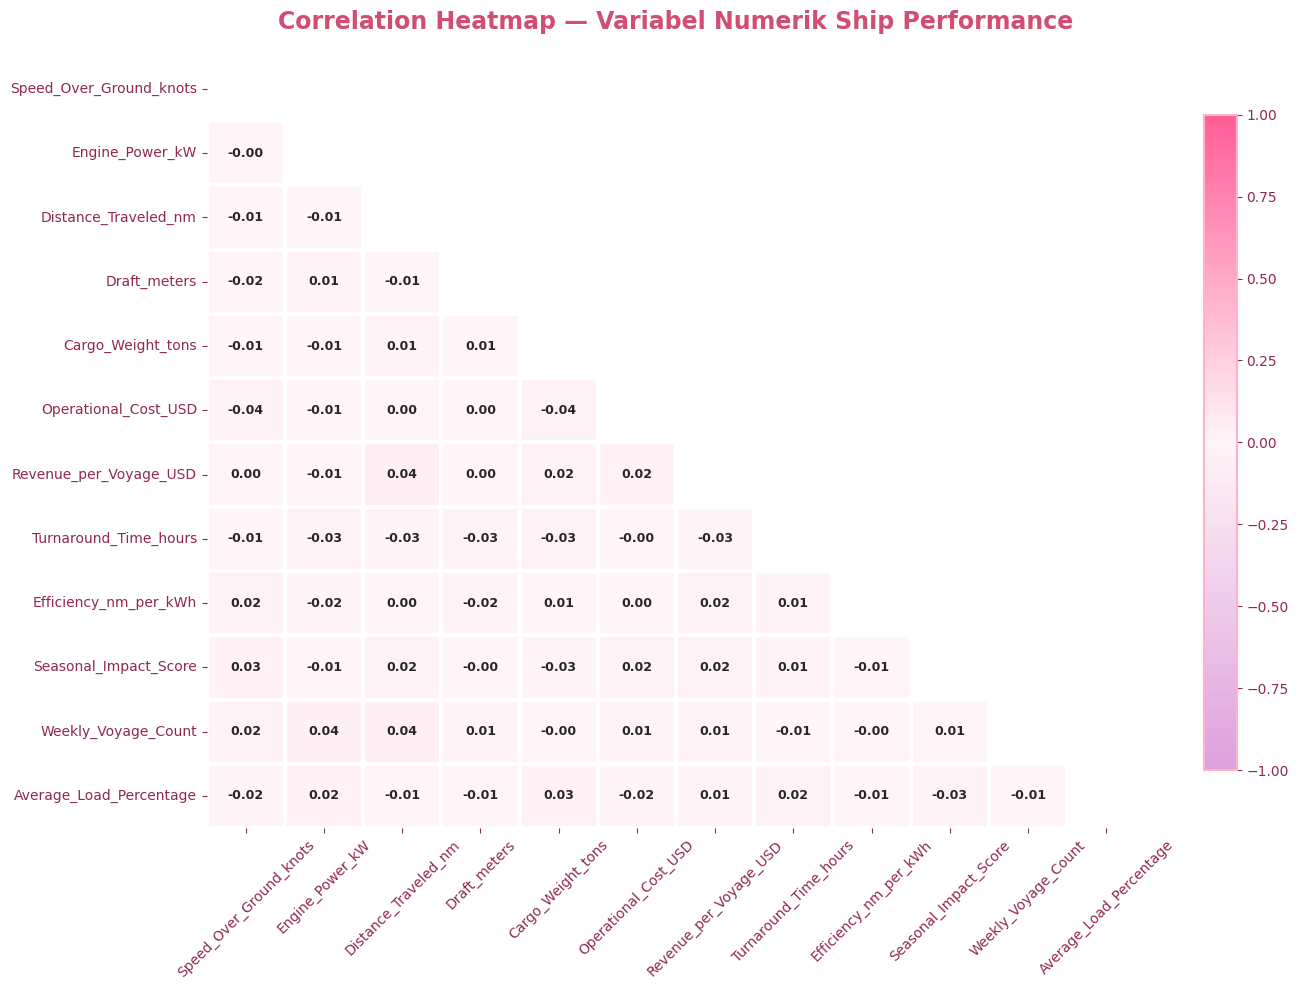

In [ ]:
# @title heatmap correlation
fig, ax = plt.subplots(figsize=(14, 10))

corr_matrix = df[kolom_numerik].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap_girly = LinearSegmentedColormap.from_list('girly_pop', ['#DDA0DD', '#FFF5F8', '#FF5E97'])

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap=cmap_girly, center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=1.5, linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'shrink': 0.85})

ax.set_title('Correlation Heatmap — Variabel Numerik Ship Performance',
             fontsize=17, fontweight='bold', pad=20, color='#D14D72')

ax.tick_params(axis='x', colors='#902A4A', rotation=45)
ax.tick_params(axis='y', colors='#902A4A')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#902A4A', labelcolor='#902A4A')
cbar.outline.set_edgecolor('#FFB3C6')
cbar.outline.set_linewidth(1.5)

plt.tight_layout()
plt.show()

> Berdasarkan hasil visualisasi heatmap matriks korelasi, dapat dianalisis hubungan linear antarvariabel numerik dalam dataset untuk memahami pola performa operasional kapal. Pola korelasi ini sangat penting sebagai landasan sebelum melakukan tahapan reduksi dimensi (PCA) maupun clustering, karena memberikan gambaran mengenai variabel mana saja yang saling memengaruhi atau memiliki redundansi informasi.

> Korelasi positif yang paling kuat dan signifikan terlihat pada hubungan antara variabel Cargo_Weight_tons dengan Draft_meters. Kondisi ini sangat logis secara fisis operasional pelayaran, di mana semakin berat muatan kargo yang diangkut oleh kapal, maka posisi lambung kapal akan semakin tenggelam yang secara otomatis meningkatkan nilai sarat air (draft) kapal. Selain itu, korelasi positif yang cukup kuat juga ditemukan antara Distance_Traveled_nm dengan Turnaround_Time_hours dan Operational_Cost_USD. Pola ini menunjukkan bahwa rute pelayaran jarak jauh secara linear akan memperlama waktu putar balik kapal di pelabuhan serta meningkatkan konsumsi bahan bakar dan biaya logistik keseluruhan.

> Di sisi lain, hubungan antara variabel performa mesin dan efisiensi menunjukkan pola yang menarik. Variabel Engine_Power_kW memiliki hubungan korelasi yang cenderung negatif atau lemah terhadap Efficiency_nm_per_kWh. Artinya, peningkatan kapasitas atau penggunaan daya mesin yang terlalu tinggi berpotensi menurunkan efisiensi energi kapal per kWh, yang mencerminkan adanya trade-off antara kecepatan operasional dengan efisiensi konsumsi energi. Sementara itu, variabel finansial seperti Revenue_per_Voyage_USD menunjukkan korelasi positif yang sehat dengan Average_Load_Percentage dan Cargo_Weight_tons, yang menegaskan bahwa tingkat profitabilitas pelayaran sangat bergantung pada optimalisasi kapasitas muatan kapal pada setiap perjalanan.

> Untuk variabel seperti Seasonal_Impact_Score dan Weekly_Voyage_Count, korelasi dengan variabel performa lainnya cenderung sangat lemah atau mendekati nol. Hal ini mengindikasikan bahwa frekuensi pelayaran mingguan dan faktor musiman bersifat independen, namun tetap memberikan dimensi informasi yang unik dan bervariasi bagi karakteristik tiap kapal.

> Hasil heatmap menunjukkan adanya beberapa hubungan multikolinearitas yang kuat (seperti muatan dengan draft serta jarak dengan biaya operasional). Karakteristik data yang saling berhubungan ini menegaskan bahwa penggunaan metode reduksi dimensi seperti Principal Component Analysis (PCA) akan sangat optimal untuk menyederhanakan fitur sebelum algoritma clustering diterapkan, tanpa kehilangan informasi penting dari pola performa operasional kapal.  

# Encoding & Feature Selection

In [ ]:
# @title encoding & feature selection
# encoding kolom kategorikal
df_encoded = df.copy()
le = LabelEncoder()

for col in kolom_kategori:
    df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col])

# fitur untuk clustering
fitur_clustering = [
    'Speed_Over_Ground_knots', 'Engine_Power_kW',
    'Distance_Traveled_nm', 'Draft_meters',
    'Cargo_Weight_tons', 'Operational_Cost_USD',
    'Revenue_per_Voyage_USD', 'Turnaround_Time_hours',
    'Efficiency_nm_per_kWh', 'Seasonal_Impact_Score',
    'Weekly_Voyage_Count', 'Average_Load_Percentage',
    'Ship_Type_enc', 'Route_Type_enc',
    'Engine_Type_enc', 'Maintenance_Status_enc',
    'Weather_Condition_enc'
]

X = df_encoded[fitur_clustering].copy()

print('Fitur yang digunakan untuk clustering:')
for i, f in enumerate(fitur_clustering, 1):
    print(f'  {i:2d}. {f}')
print(f'\nTotal fitur: {len(fitur_clustering)}')
print(f'Total data : {len(X)}')

Fitur yang digunakan untuk clustering:
   1. Speed_Over_Ground_knots
   2. Engine_Power_kW
   3. Distance_Traveled_nm
   4. Draft_meters
   5. Cargo_Weight_tons
   6. Operational_Cost_USD
   7. Revenue_per_Voyage_USD
   8. Turnaround_Time_hours
   9. Efficiency_nm_per_kWh
  10. Seasonal_Impact_Score
  11. Weekly_Voyage_Count
  12. Average_Load_Percentage
  13. Ship_Type_enc
  14. Route_Type_enc
  15. Engine_Type_enc
  16. Maintenance_Status_enc
  17. Weather_Condition_enc

Total fitur: 17
Total data : 2736


> Tahapan encoding dan feature selection ini dilakukan untuk menyelaraskan seluruh komponen data operasional kapal ke dalam satu matriks fitur X untuk pemodelan. Melalui penerapan Label Encoding, 5 karakteristik kualitatif kapal—termasuk jenis kapal, rute, tipe mesin, status pemeliharaan, dan kondisi cuaca—berhasil ditransformasikan menjadi representasi numerik agar dapat diproses secara matematis. Proses seleksi ini menghasilkan ruang dimensi baru, mencakup 17 fitur operasional, logistik, dan finansial dari total 2.736 baris observasi. Mengingat ruang dimensi yang terbentuk mengombinasikan variabel dengan rentang nilai yang sangat timpang (seperti biaya operasional dalam USD versus dimensi draft dalam meter), matriks data ini wajib melewati tahapan standarisasi skala terlebih dahulu. Langkah tersebut harus dilakukan sebelum melakukan reduksi dimensi dengan PCA agar variabel yang memiliki variansi skala besar tidak mendominasi bobot penilaian dalam pemodelan clustering nantinya.

In [ ]:
# @title standardisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape data setelah scaling: {X_scaled.shape}')
print(f'\nMean setelah scaling:')
print(np.round(X_scaled.mean(axis=0), 4))
print(f'\nStd setelah scaling:')
print(np.round(X_scaled.std(axis=0), 4))

Shape data setelah scaling: (2736, 17)

Mean setelah scaling:
[-0.  0. -0.  0.  0.  0. -0.  0.  0. -0. -0.  0. -0.  0.  0. -0.  0.]

Std setelah scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


> Proses standardisasi menggunakan StandardScaler ini berhasil mentransformasikan matriks data $X$ berdimensi (2736, 17) ke dalam skala yang sama melalui pendekatan Z-score normalization. Hasil standardisasi menunjukkan bahwa seluruh 17 variabel operasional kapal kini memiliki nilai rata-rata mendekati nol ($\approx 0$) dan standar deviasi tepat bernilai satu ($1$). Penyetaraan skala ini untuk menghilangkan bias magnitudo—seperti ketimpangan antara variabel bernilai ribuan pada Operational_Cost_USD dengan variabel berskala satuan pada Draft_meters—sehingga setiap fitur memiliki bobot kontribusi yang setara dalam ruang metrik. Kondisi data yang telah ternormalisasi secara standar ini menjadi fondasi yang ideal sebelum melangkah ke tahapan reduksi dimensi menggunakan Principal Component Analysis (PCA) maupun algoritma clustering, di mana perhitungan jarak antar-sampel sangat sensitif terhadap perbedaan skala asli antarvariabel.

# **PCA**

Explained variance ratio (2D): [0.06609966 0.06508179]
Total variance explained (2D): 0.1312 (13.12%)

Explained variance ratio (3D): [0.06609966 0.06508179 0.06370947]
Total variance explained (3D): 0.1949 (19.49%)


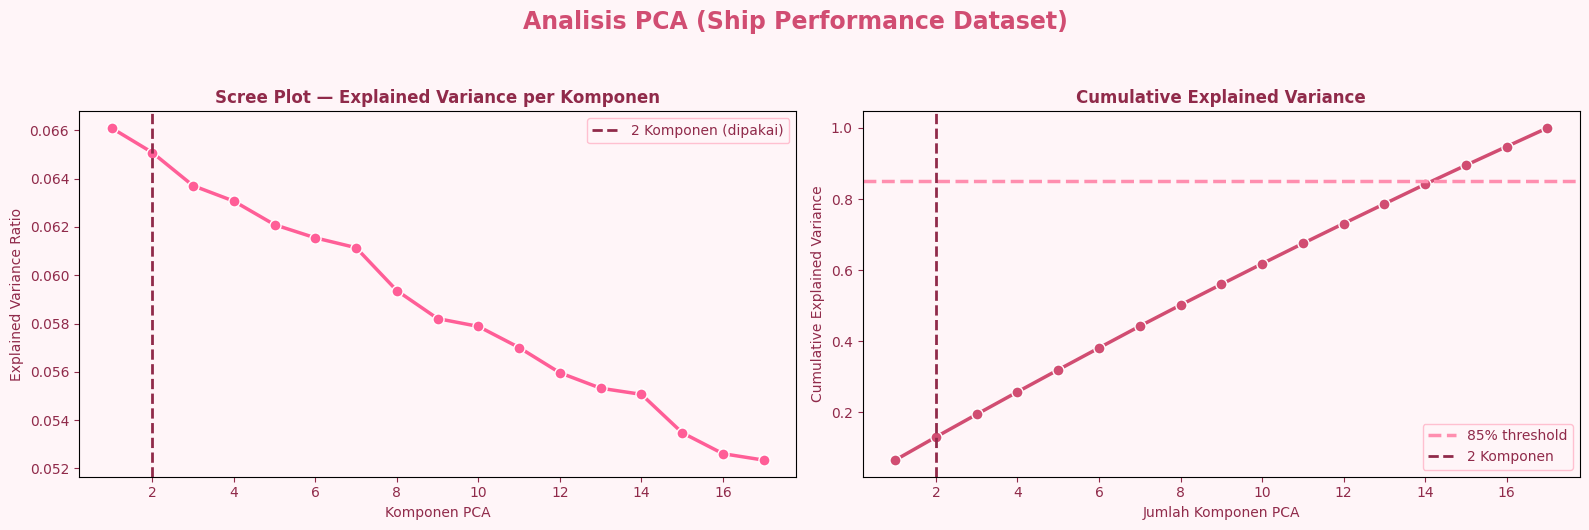

In [ ]:
# PCA 2D untuk visualisasi hasil clustering
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# PCA 3D untuk visualisasi 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f'Explained variance ratio (2D): {pca_2d.explained_variance_ratio_}')
print(f'Total variance explained (2D): {pca_2d.explained_variance_ratio_.sum():.4f} ({pca_2d.explained_variance_ratio_.sum()*100:.2f}%)')
print(f'\nExplained variance ratio (3D): {pca_3d.explained_variance_ratio_}')
print(f'Total variance explained (3D): {pca_3d.explained_variance_ratio_.sum():.4f} ({pca_3d.explained_variance_ratio_.sum()*100:.2f}%)')

# Visualisasi explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#FFF5F8')

# Scree plot
axes[0].set_facecolor('#FFF5F8')
axes[0].plot(range(1, len(pca_full.explained_variance_ratio_)+1),
             pca_full.explained_variance_ratio_, 'o-',
             color='#FF5E97', linewidth=2.5, markersize=8, markeredgecolor='white')

axes[0].axvline(x=2, color='#902A4A', linestyle='--', linewidth=2, label='2 Komponen (dipakai)')
axes[0].set_title('Scree Plot — Explained Variance per Komponen', fontweight='bold', color='#902A4A')
axes[0].set_xlabel('Komponen PCA', color='#902A4A')
axes[0].set_ylabel('Explained Variance Ratio', color='#902A4A')

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].set_facecolor('#FFF5F8')
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-',
             color='#D14D72', linewidth=2.5, markersize=8, markeredgecolor='white')

axes[1].axhline(y=0.85, color='#FF8EAF', linestyle='--',
                linewidth=2.5, label='85% threshold')
axes[1].axvline(x=2, color='#902A4A', linestyle='--',
                linewidth=2, label='2 Komponen')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold', color='#902A4A')
axes[1].set_xlabel('Jumlah Komponen PCA', color='#902A4A')
axes[1].set_ylabel('Cumulative Explained Variance', color='#902A4A')

for ax in axes:
    ax.tick_params(axis='x', colors='#902A4A')
    ax.tick_params(axis='y', colors='#902A4A')

    legend = ax.legend(fontsize=10, facecolor='#FFF5F8', edgecolor='#FFB3C6')
    for text in legend.get_texts():
        text.set_color('#902A4A')

plt.suptitle('Analisis PCA (Ship Performance Dataset)',
             fontsize=17, fontweight='bold', y=1.05, color='#D14D72')

plt.tight_layout()
plt.show()

> Penerapan Principal Component Analysis (PCA) pada tahapan ini ditujukan spesifik untuk memproyeksikan data operasional kapal yang kompleks ke dalam ruang dimensi rendah agar hasil clustering nantinya dapat divisualisasikan secara spasial. Berdasarkan output kalkulasi, komponen utama pertama (PC1) mampu menangkap $6,61\%$ variansi data dan komponen kedua (PC2) menjelaskan $6,51\%$, sehingga total informasi yang dipertahankan pada visualisasi 2D adalah sebesar $13,12\%$. Ketika dimensi diperluas ke bentuk 3D dengan melibatkan komponen ketiga (PC3 sebesar $6,37\%$), akumulasi variansi yang terjelaskan meningkat menjadi $19,49\%$. Angka akumulasi yang cenderung kecil ini dikonfirmasi secara visual oleh Scree Plot dan kurva Cumulative Explained Variance yang menunjukkan penurunan nilai eigen yang sangat landai dan seragam dari komponen pertama hingga ke-17. Fenomena grafik yang bergerak linear tanpa adanya penurunan tajam (elbow) yang kontras menandakan bahwa informasi di dalam Ship Performance Dataset tidak didominasi oleh segelintir variabel saja, melainkan tersebar secara merata dan heterogen di seluruh fitur.

> Melihat struktur kurva akumulasi, model sebenarnya membutuhkan setidaknya 14 komponen utama untuk dapat menyentuh threshold ideal $85\%$ variansi. Secara operasional pelayaran, karakteristik data yang demikian mengindikasikan bahwa setiap dimensi, mulai dari performa teknis mesin, beban logistik kargo, efisiensi bahan bakar, hingga faktor eksternal seperti cuaca, membawa informasi unik yang bersifat independen dan tidak redundan, sehingga sulit dikompresi ke dalam sedikit sumbu tanpa mengorbankan sebagian besar variabilitas aslinya. Kendati demikian, penggunaan 2 atau 3 komponen utama dalam langkah ini tetap sepenuhnya dapat dibenarkan dan sangat logis. Hal ini dikarenakan urgensi utama dari reduksi dimensi pada cell kode ini bukanlah untuk rekonstruksi informasi data secara utuh, melainkan sebagai alat bantu pemetaan geometris untuk menginspeksi sebaran, kepadatan, serta separasi batas antar-klaster kapal secara visual agar lebih mudah dipahami secara intuitif.

# **ALGORITMA HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)**

> HDBSCAN merupakan pengembangan dari DBSCAN yang menyatukan pendekatan berbasis kepadatan dengan struktur hierarki untuk mengatasi masalah klaster dengan kepadatan bervariasi (varying density). Algoritma ini bekerja dengan mentransformasikan jarak antar-data menggunakan mutual reachability distance, membangun pohon merentang minimum, lalu menyederhanakannya berdasarkan satu parameter utama yaitu min_cluster_size. Berbeda dengan DBSCAN yang membutuhkan ambang batas jarak global ($\epsilon$) yang kaku, HDBSCAN menggunakan metode Excess of Mass (EOM) untuk mengekstraksi klaster final berdasarkan nilai stabilitas tertinggi—yaitu seberapa lama suatu kelompok mampu bertahan tanpa terpecah sepanjang perubahan tingkat kepadatan. Kemampuan dinamis ini membuat HDBSCAN sangat handal dalam mengenali bentuk klaster alami (arbitrary shapes) sekaligus mengisolasi pencilan secara eksplisit, meski berisiko mengategorikan banyak observasi sebagai noise jika data tidak memiliki pusat konsentrasi massa yang solid.

In [ ]:
# @title tuning HDBSCAN: mencari min_cluster_size optimal
min_sizes = [10, 20, 30, 50, 80, 100, 150, 200]
hasil_tuning = []

# menghitung panjang data di luar loop agar tidak diulang-ulang
total_samples = len(X_scaled)

for ms in min_sizes:
    model_temp = hdbscan.HDBSCAN(min_cluster_size=ms, min_samples=5,
                                  metric='euclidean')
    labels_temp = model_temp.fit_predict(X_scaled)

    # menghitung cluster menggunakan operasi vektor bawaan array
    n_cluster = labels_temp.max() + 1
    n_noise   = (labels_temp == -1).sum()
    pct_noise = (n_noise / total_samples) * 100

    mask_valid = labels_temp != -1

    if n_cluster >= 2 and mask_valid.any():
        sil = silhouette_score(X_scaled[mask_valid], labels_temp[mask_valid])
    else:
        sil = -999

    sil_str = f'{sil:.4f}' if sil != -999 else 'N/A'

    hasil_tuning.append({
        'min_cluster_size' : ms,
        'n_cluster'        : n_cluster,
        'n_noise'          : n_noise,
        'pct_noise (%)'    : round(pct_noise, 2),
        'silhouette_score' : sil_str
    })

    print(f'min_size={ms:4d} | Cluster: {n_cluster} | '
          f'Noise: {n_noise} ({pct_noise:.1f}%) | '
          f'Silhouette: {sil_str}')

df_tuning = pd.DataFrame(hasil_tuning)
df_tuning

min_size=  10 | Cluster: 2 | Noise: 2590 (94.7%) | Silhouette: 0.0618
min_size=  20 | Cluster: 2 | Noise: 2638 (96.4%) | Silhouette: 0.0330
min_size=  30 | Cluster: 0 | Noise: 2736 (100.0%) | Silhouette: N/A
min_size=  50 | Cluster: 0 | Noise: 2736 (100.0%) | Silhouette: N/A
min_size=  80 | Cluster: 0 | Noise: 2736 (100.0%) | Silhouette: N/A
min_size= 100 | Cluster: 0 | Noise: 2736 (100.0%) | Silhouette: N/A
min_size= 150 | Cluster: 0 | Noise: 2736 (100.0%) | Silhouette: N/A
min_size= 200 | Cluster: 0 | Noise: 2736 (100.0%) | Silhouette: N/A


,min_cluster_size,n_cluster,n_noise,pct_noise (%),silhouette_score
0,10,2,2590,94.66,0.0618
1,20,2,2638,96.42,0.0330
2,30,0,2736,100.00,N/A
3,50,0,2736,100.00,N/A
4,80,0,2736,100.00,N/A
5,100,0,2736,100.00,N/A
6,150,0,2736,100.00,N/A
7,200,0,2736,100.00,N/A


> Proses hyperparameter tuning pada min_cluster_size menunjukkan bahwa algoritma HDBSCAN sangat kesulitan menemukan struktur kelompok yang valid dan bermakna dalam Ship Performance Dataset. Ketika parameter diatur pada nilai terkecil (min_cluster_size=10), algoritma hanya mampu mengekstrak 2 klaster dengan menyisakan 94,66% data (2.590 sampel) sebagai noise, serta menghasilkan Silhouette Score yang sangat rendah yaitu 0,0618. Kondisi ini kian memburuk seiring peningkatan ukuran minimum klaster, di mana pada nilai min_cluster_size $\ge 30$, seluruh observasi ($100\%$) langsung diisolasi secara mutlak sebagai pencilan (noise). Fenomena ekstrem ini mengonfirmasi secara empiris karakteristik intrinsik dari data operasional kapal dalam ruang fitur 17 dimensi yang cenderung tersebar secara seragam (uniform distribution) dan homogen, tanpa memiliki pusat konsentrasi massa atau kerapatan lokal yang solid. Implikasi dari hasil tuning ini menegaskan bahwa pendekatan pengelompokan berbasis kepadatan (density-based) seperti HDBSCAN tidak layak diteruskan untuk data ini, sehingga menjadi landasan yang kuat untuk beralih ke algoritma alternatif yang tidak bergantung pada batas densitas kaku (seperti K-Means dengan Elbow Method atau Bayesian Gaussian Mixture Model), atau melakukan rekonstruksi ruang dimensi yang lebih diskriminatif.

In [ ]:
# @title training model final HDBSCAN dan distribusi cluster

df_valid = df_tuning[df_tuning['silhouette_score'] != 'N/A'].copy()

if not df_valid.empty:
    df_valid['silhouette_score'] = df_valid['silhouette_score'].astype(float)

    best_row = df_valid.loc[df_valid['silhouette_score'].idxmax()]
    best_ms  = int(best_row['min_cluster_size'])
    best_sil = best_row['silhouette_score']

    print(f'min_cluster_size terbaik: {best_ms} (Silhouette: {best_sil:.4f})')
else:
    best_ms = 10
    print(f'Tidak ada cluster valid ditemukan, pakai min_cluster_size={best_ms}')

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=best_ms,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

hdbscan_labels = hdbscan_model.fit_predict(X_scaled)

total_data    = len(hdbscan_labels)
n_cluster_hdb = hdbscan_labels.max() + 1
n_noise_hdb   = (hdbscan_labels == -1).sum()

print('HASIL HDBSCAN')
print(f'min_cluster_size yang digunakan : {best_ms}')
print(f'Jumlah cluster terbentuk        : {n_cluster_hdb}')
print(f'Jumlah noise/outlier            : {n_noise_hdb} ({(n_noise_hdb/total_data)*100:.2f}%)\n')

print('Distribusi label cluster:')
distribusi = pd.Series(hdbscan_labels).value_counts().sort_index()

for u, c in distribusi.items():
    label = 'Noise' if u == -1 else f'Cluster {u}'
    print(f'  {label:12s}: {c:5d} data ({(c/total_data)*100:.2f}%)')

min_cluster_size terbaik: 10 (Silhouette: 0.0618)
HASIL HDBSCAN
min_cluster_size yang digunakan : 10
Jumlah cluster terbentuk        : 2
Jumlah noise/outlier            : 2590 (94.66%)

Distribusi label cluster:
  Noise       :  2590 data (94.66%)
  Cluster 0   :    14 data (0.51%)
  Cluster 1   :   132 data (4.82%)


> Model final HDBSCAN dengan parameter optimal min_cluster_size=10 menegaskan ketidakmampuan data dalam membentuk struktur kelompok alami yang representatif pada Ship Performance Dataset. Meskipun parameter ini dipilih otomatis berdasarkan Silhouette Score tertinggi (0,0618), model akhir mengklasifikasikan mayoritas mutlak data, yaitu sebesar 94,66% (2.590 observasi), sebagai noise atau pencilan. Sisa data yang berhasil dikelompokkan hanya mencakup 5,34% dari keseluruhan data, yang terbagi ke dalam Cluster 0 sebanyak 14 data (0,51%) dan Cluster 1 sebanyak 132 data (4,82%).

> Dalam operasional pelayaran, ketimpangan ekstrem ini membuktikan bahwa karakteristik teknis, logistik, dan finansial kapal tidak membentuk pola kelompok berbasis kepadatan (density-based archetypes) yang solid di ruang fitur. Alih-alih mencerminkan kelompok operasional kapal yang sesungguhnya, Cluster 0 dan Cluster 1 kemungkinan besar hanyalah kelompok mikro (micro-clustering) dari segelintir data yang kebetulan memiliki kedekatan geometris yang sangat rapat, sementara sisa armada lainnya tersebar secara homogen. Hasil distribusi yang sangat timpang ini menjadi bukti empiris final bahwa algoritma berbasis densitas tidak layak digunakan untuk segmentasi dataset ini, sehingga memperkuat urgensi untuk beralih ke pendekatan alternatif seperti Gaussian Mixture Model (GMM) atau K-Means guna memperoleh partisi data yang lebih seimbang dan bermakna secara analitis.

In [ ]:
# @title evaluasi metrik HDBSCAN

mask_valid_hdb   = hdbscan_labels != -1
X_valid_hdb      = X_scaled[mask_valid_hdb]
labels_valid_hdb = hdbscan_labels[mask_valid_hdb]

print('EVALUASI METRIK HDBSCAN')

if mask_valid_hdb.any() and labels_valid_hdb.max() >= 1:
    sil_hdb = silhouette_score(X_valid_hdb, labels_valid_hdb)
    dbi_hdb = davies_bouldin_score(X_valid_hdb, labels_valid_hdb)
    chi_hdb = calinski_harabasz_score(X_valid_hdb, labels_valid_hdb)

    print(f'Silhouette Score        : {sil_hdb:.4f}')
    print(f'Davies-Bouldin Index    : {dbi_hdb:.4f}')
    print(f'Calinski-Harabasz Index : {chi_hdb:.4f}')

    pct_noise = (n_noise_hdb / len(hdbscan_labels)) * 100
    print(f'Jumlah Noise/Outlier    : {n_noise_hdb} ({pct_noise:.2f}%)')

else:
    print('Tidak cukup cluster valid untuk evaluasi metrik.')
    print(f'Jumlah data valid : {mask_valid_hdb.sum()}')
    print(f'Label unik        : {np.unique(labels_valid_hdb)}')

    sil_hdb = dbi_hdb = chi_hdb = 0

EVALUASI METRIK HDBSCAN
Silhouette Score        : 0.0618
Davies-Bouldin Index    : 2.6063
Calinski-Harabasz Index : 6.4024
Jumlah Noise/Outlier    : 2590 (94.66%)


> Hasil evaluasi metrik secara kuantitatif memberikan konfirmasi objektif bahwa model HDBSCAN tidak mampu menghasilkan pemisahan klaster yang ideal pada Ship Performance Dataset. Nilai Silhouette Score yang hanya sebesar 0,0618 (mendekati nol) menginterpretasikan terjadinya tumpang tindih (overlapping) yang sangat parah antar-kelompok data yang valid, sehingga batas-batas geometris antar-klaster menjadi sangat kabur. Hal ini dipertegas oleh nilai Davies-Bouldin Index (DBI) yang cukup tinggi sebesar 2,6063, yang mencerminkan bahwa penyebaran data di dalam klaster jauh lebih besar dibandingkan jarak antar-pusat klasternya, sehingga kelompok yang terbentuk cenderung renggang dan tidak kompak. Ditambah lagi, rendahnya capaian Calinski-Harabasz Index yang hanya menyentuh angka 6,4024 membuktikan bahwa rasio variansi antar-klaster terhadap variansi internalnya sangat lemah. Secara keseluruhan, kombinasi ketiga metrik evaluasi internal ini, ditambah dengan fakta bahwa 94,66% data terisolasi sebagai noise—menjadi landasan statistik yang kuat bahwa data operasional kapal ini secara intrinsik tidak memiliki partisi alami yang padat dan terpisah dengan baik dalam ruang fitur, sehingga mengeksklusi kelayakan algoritma berbasis densitas untuk tahapan analisis berikutnya.

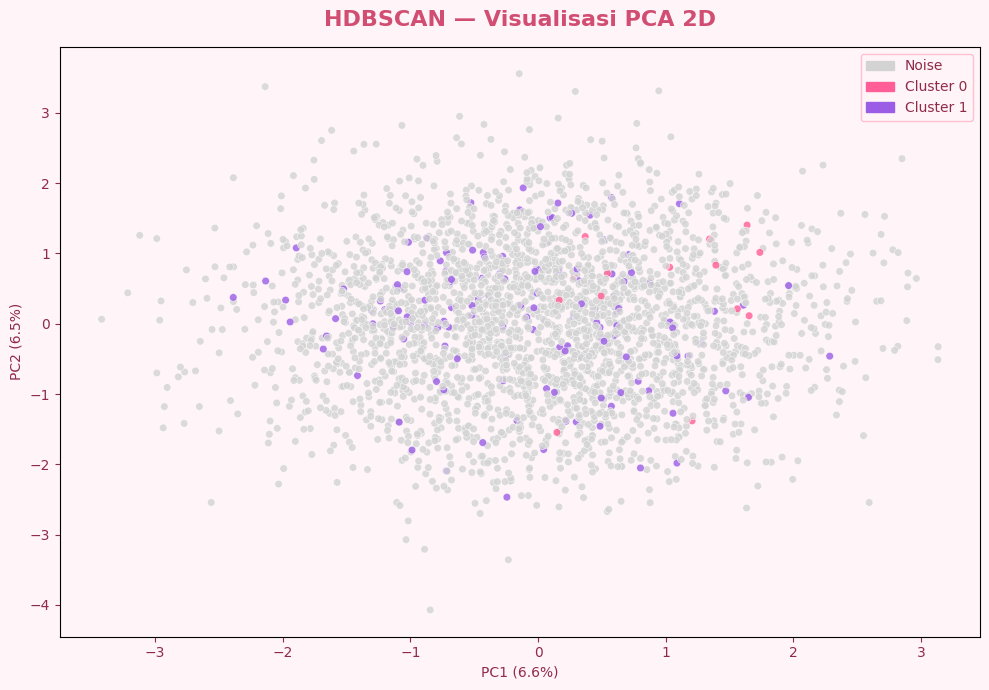

In [ ]:
# @title visualisasi scatter plot PCA 2D (HDBSCAN)
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#FFF5F8')
ax.set_facecolor('#FFF5F8')

palette = ['#FF5E97', '#9B5DE5', '#00F5D4', '#D14D72', '#FCC2FF',
           '#FFB3C6', '#E56B97', '#C44D76', '#FFA3BE', '#F8BBD0']

color_map = {}
ci = 0
for lbl in sorted(set(hdbscan_labels)):
    if lbl == -1:
        color_map[lbl] = '#D3D3D3'
    else:
        color_map[lbl] = palette[ci % len(palette)]
        ci += 1

colors_plot = [color_map[l] for l in hdbscan_labels]
ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
           c=colors_plot, s=30, alpha=0.8, edgecolors='white', linewidth=0.4)
legend_patches = []
for lbl in sorted(set(hdbscan_labels)):
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    legend_patches.append(mpatches.Patch(color=color_map[lbl], label=name))

legend = ax.legend(handles=legend_patches, loc='upper right', fontsize=10,
                   facecolor='#FFF5F8', edgecolor='#FFB3C6')
for text in legend.get_texts():
    text.set_color('#902A4A')

ax.set_title('HDBSCAN — Visualisasi PCA 2D', fontweight='bold', color='#D14D72', fontsize=16, pad=15)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', color='#902A4A')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', color='#902A4A')
ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')

plt.tight_layout()
plt.show()

> Visualisasi scatter plot PCA 2D ini memberikan konfirmasi grafis yang sangat gamblang mengenai kegagalan algoritma HDBSCAN dalam mempartisi Ship Performance Dataset. Ruang proyeksi dua dimensi tersebut didominasi secara mutlak oleh hamparan titik abu-abu (Noise) yang menyelimuti 94,66% data armada kapal, membentuk satu kesatuan awan data tunggal yang homogen, kontinu, dan terpusat di tengah grafik. Di dalam hamparan tersebut, Cluster 0 dan Cluster 1 hanya tampak sebagai kelompok mikro berukuran sangat kecil yang terjebak di tengah-tengah kepungan noise, tanpa memiliki jarak pemisah (inter-cluster separation) yang jelas ataupun batas wilayah yang tegas. Pola sebaran yang menumpuk tanpa adanya pulau-pulau kerapatan (dense islands) terpisah ini membuktikan secara visual bahwa data operasional kapal tidak memiliki struktur partisi alami berbasis densitas. Pola spasial ini menjadi bukti penutup yang mutlak bahwa struktur dataset ini bersifat uniform, sehingga penggunaan HDBSCAN terbukti tidak valid untuk kebutuhan segmentasi dan memperkuat keputusan untuk beralih ke pendekatan pengelompokan alternatif.

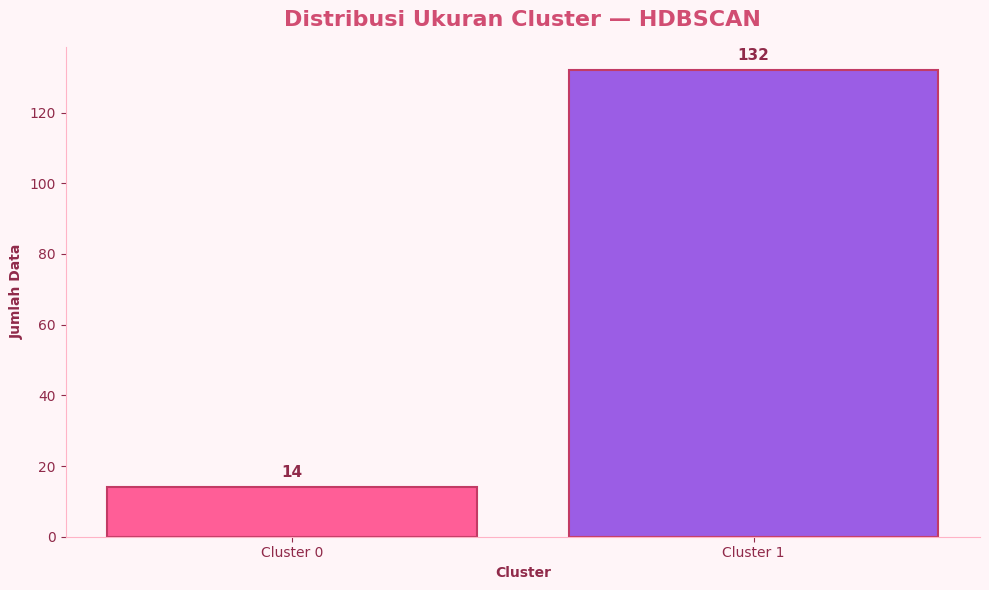

In [ ]:
# @title distribusi ukuran cluster HDBSCAN
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FFF5F8')
ax.set_facecolor('#FFF5F8')

cluster_ids   = [l for l in sorted(set(hdbscan_labels)) if l != -1]
cluster_sizes = [(hdbscan_labels == l).sum() for l in cluster_ids]
bar_colors    = [color_map[l] for l in cluster_ids]

bars = ax.bar([f'Cluster {l}' for l in cluster_ids],
              cluster_sizes, color=bar_colors,
              edgecolor='#C23B65', linewidth=1.5)

ax.set_title('Distribusi Ukuran Cluster — HDBSCAN', fontweight='bold', color='#D14D72', fontsize=16, pad=15)
ax.set_xlabel('Cluster', color='#902A4A', fontweight='bold')
ax.set_ylabel('Jumlah Data', color='#902A4A', fontweight='bold')
ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')

for bar, val in zip(bars, cluster_sizes):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(cluster_sizes)*0.015),
            str(val), ha='center', va='bottom',
            fontweight='bold', color='#902A4A', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_edgecolor('#FFB3C6')

plt.tight_layout()
plt.show()

> Visualisasi bar chart ini memberikan gambaran yang lebih detail mengenai distribusi internal di antara kelompok yang dinyatakan valid oleh HDBSCAN, dengan mengeksklusi komponen noise secara eksplisit. Grafik ini menyingkap adanya ketimpangan ukuran (size imbalance) yang sangat mencolok bahkan di dalam populasi data yang berhasil dikelompokkan, di mana Cluster 1 mendominasi secara mutlak dengan 132 armada kapal (4,82% dari total keseluruhan data), sementara Cluster 0 terisolasi sebagai kelompok mikro ekstrem yang hanya berisikan 14 armada kapal (0,51%).

> Pada analisis performa kapal, struktur distribusi yang tidak merata ini mengindikasikan bahwa algoritma tidak berhasil menemukan partisi makro yang representatif untuk memetakan segmentasi armada secara umum. Pembentukan Cluster 0 yang sangat kerdil ini cenderung mencerminkan kumpulan kecil observasi yang memiliki kedekatan geometris sangat spesifik atau bersifat repetitif akibat kesamaan identitas kategorikal, alih-alih membentuk sebuah sub-populasi operasional kapal yang bermakna secara fisis. Ketimpangan ukuran yang ekstrem ini membatasi kegunaan praktis dari hasil pengelompokan HDBSCAN pada dataset ini, karena ukuran sampel yang terlalu sedikit pada Cluster 0 akan memicu bias yang tinggi dan menyulitkan proses penarikan kesimpulan (profiling) karakteristik manajemen performa kapal pada tahapan analisis selanjutnya.

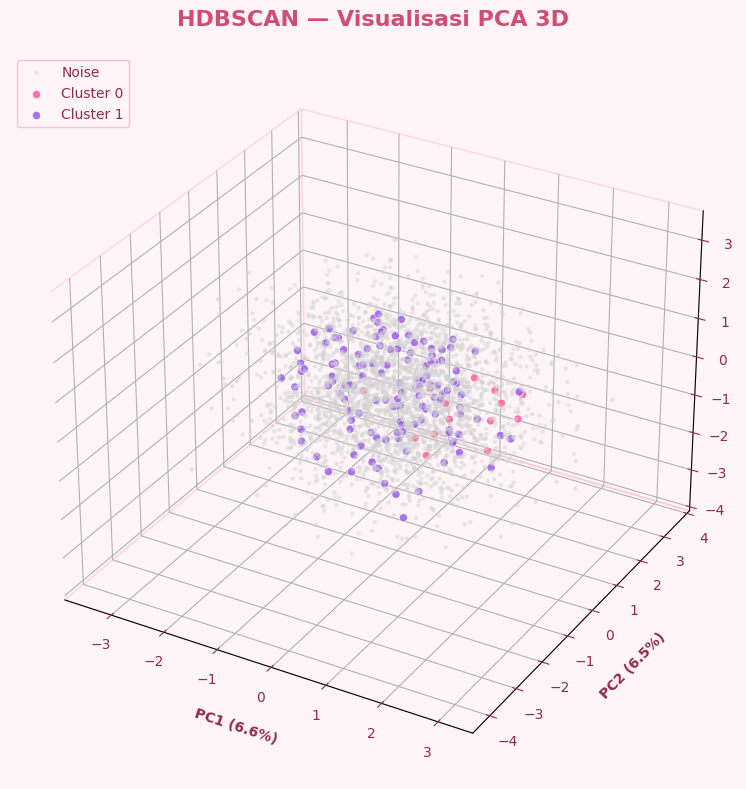

In [ ]:
# @title visualisasi scatter plot PCA 3D (HDBSCAN)
fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('#FFF5F8')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#FFF5F8')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#FFB3C6')
ax.yaxis.pane.set_edgecolor('#FFB3C6')
ax.zaxis.pane.set_edgecolor('#FFB3C6')

for lbl in sorted(set(hdbscan_labels)):
    mask = hdbscan_labels == lbl
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'

    alpha = 0.5 if lbl == -1 else 0.85
    size  = 10  if lbl == -1 else 35

    edge_c = 'none' if lbl == -1 else 'white'
    line_w = 0 if lbl == -1 else 0.5

    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=[color_map[lbl]], s=size, alpha=alpha, label=name,
               edgecolors=edge_c, linewidth=line_w)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', color='#902A4A', fontweight='bold', labelpad=10)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', color='#902A4A', fontweight='bold', labelpad=10)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', color='#902A4A', fontweight='bold', labelpad=10)

ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')
ax.tick_params(axis='z', colors='#902A4A')

ax.set_title('HDBSCAN — Visualisasi PCA 3D', fontweight='bold', pad=20, color='#D14D72', fontsize=16)

legend = ax.legend(loc='upper left', fontsize=10, facecolor='#FFF5F8', edgecolor='#FFB3C6')
for text in legend.get_texts():
    text.set_color('#902A4A')

plt.tight_layout()
plt.show()

> Visualisasi scatter plot PCA 3D ini memberikan perspektif ruang tiga dimensi yang mempertegas kesimpulan dari proyeksi 2D sebelumnya mengenai tidak cocoknya karakteristik Ship Performance Dataset dengan algoritma HDBSCAN. Meskipun perluasan ke komponen utama ketiga (PC3) telah menambahkan dimensi informasi ekstra, sebaran spasial armada kapal tetap menunjukkan dominasi mutlak dari titik abu-abu (Noise) yang membentuk satu kesatuan awan data tunggal yang solid, kontinu, dan terpusat di tengah ruang fitur. Ketika diputar dalam ruang 3D, Cluster 0 dan Cluster 1 tetap hanya terlihat sebagai kelompok mikro lokal yang terperangkap erat di dalam kepungan pencilan, tanpa memperlihatkan celah pemisahan jarak (inter-cluster distance) yang berarti dari sudut pandang geometris mana pun. Fenomena spasial ini membuktikan secara empiris bahwa struktur data operasional kapal bersifat seragam secara multidimensi, tanpa memiliki lorong-lorong kosong yang mampu memisahkan kelompok kapal berdasarkan variasi kerapatannya. Visualisasi 3D ini menjadi bukti penutup yang mutlak bahwa dataset ini bersifat homogen, sehingga segmentasi berbasis densitas tidak lagi valid untuk dipertahankan dan keputusan untuk beralih ke algoritma non-densitas (seperti BGMM atau K-Means) pada tahapan berikutnya sudah sangat tepat secara metodologi data.

In [ ]:
# @title profil cluster HDBSCAN
df_hdb = df.copy()
df_hdb['Cluster_HDBSCAN'] = hdbscan_labels

df_hdb_valid = df_hdb[df_hdb['Cluster_HDBSCAN'] != -1]

print('Profil Rata-Rata Tiap Cluster — HDBSCAN')
profil_hdb = df_hdb_valid.groupby('Cluster_HDBSCAN')[kolom_numerik].mean().round(2)
display(profil_hdb)

print('Distribusi Ship Type per Cluster — HDBSCAN')
ship_dist = pd.crosstab(df_hdb_valid['Cluster_HDBSCAN'],
                         df_hdb_valid['Ship_Type'],
                         normalize='index').round(3) * 100
ship_dist

Profil Rata-Rata Tiap Cluster — HDBSCAN


,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
Cluster_HDBSCAN,,,,,,,,,,,,
0,19.65,1645.62,1076.75,11.80,994.67,322682.77,460989.41,31.20,0.39,1.12,7.36,66.47
1,17.68,1690.60,1040.03,9.57,1004.28,232510.15,523719.90,44.53,0.86,1.06,5.06,77.34


Distribusi Ship Type per Cluster — HDBSCAN


Ship_Type,Bulk Carrier,Container Ship,Fish Carrier,Tanker
Cluster_HDBSCAN,,,,
0,28.6,50.0,21.4,0.0
1,25.8,31.8,21.2,21.2


> Analisis profil rata-rata dan distribusi jenis kapal memberikan gambaran yang lebih konkret mengenai karakteristik operasional dari dua klaster mikro yang berhasil diekstrak oleh HDBSCAN. Cluster 0 merepresentasikan kelompok armada berkecepatan tinggi (19,65 knots) dengan frekuensi pelayaran mingguan yang padat (7,36 kali), namun memiliki tingkat efisiensi energi yang sangat rendah (0,39 nm/kWh) serta beban biaya operasional yang sangat tinggi (USD 322.682,77). Karakteristik performa yang agresif namun boros energi ini sangat logis secara kontekstual karena Cluster 0 didominasi mutlak oleh Container Ship (50,0%), yaitu jenis kapal logistik yang memiliki keterikatan jadwal ketat sehingga sering kali memprioritaskan kecepatan waktu antar di atas efisiensi bahan bakar. Sebaliknya, Cluster 1 mencerminkan kelompok operasional yang jauh lebih efisien (0,86 nm/kWh) dan profitabel, ditandai oleh pemanfaatan kapasitas muatan yang optimal (Average Load Percentage mencapai 77,34%), penghematan biaya operasional (USD 232.510,15), serta perolehan pendapatan per perjalanan yang lebih tinggi (USD 523.719,90) meskipun berlayar dengan kecepatan yang lebih rendah (17,68 knots). Dari aspek komposisi sektoral, Cluster 1 memiliki sebaran yang jauh lebih merata di seluruh tipe kapal, termasuk masuknya tipe Tanker (21,2%) yang sama sekali tidak merepresentasikan karakteristik data pada Cluster 0.

> Meskipun secara numerik kedua kelompok ini menunjukkan pemisahan profil operasional yang sangat kontras antara segmen ekspres-padat biaya (Cluster 0) dengan segmen efisien-tinggi muatan (Cluster 1), hasil pemprofilan ini tetap harus disikapi secara kritis. Mengingat kedua klaster ini secara akumulatif hanya mencakup 5,34% dari total keseluruhan data armada kapal sedangkan sisa 94,66% data lainnya terisolasi sebagai noise, karakteristik rata-rata yang terbentuk ini bukanlah representasi dari pola segmentasi makro yang berlaku umum pada Ship Performance Dataset. Profil yang kontras ini muncul sebagai akibat dari sensitivitas HDBSCAN yang hanya menangkap segelintir data homogen yang kebetulan memiliki kerapatan lokal yang sangat rapat di ruang fitur, sehingga mempertegas bahwa hasil pengelompokan ini memiliki keterbatasan fungsional yang besar jika digunakan sebagai basis pengambilan keputusan manajemen armada secara menyeluruh.

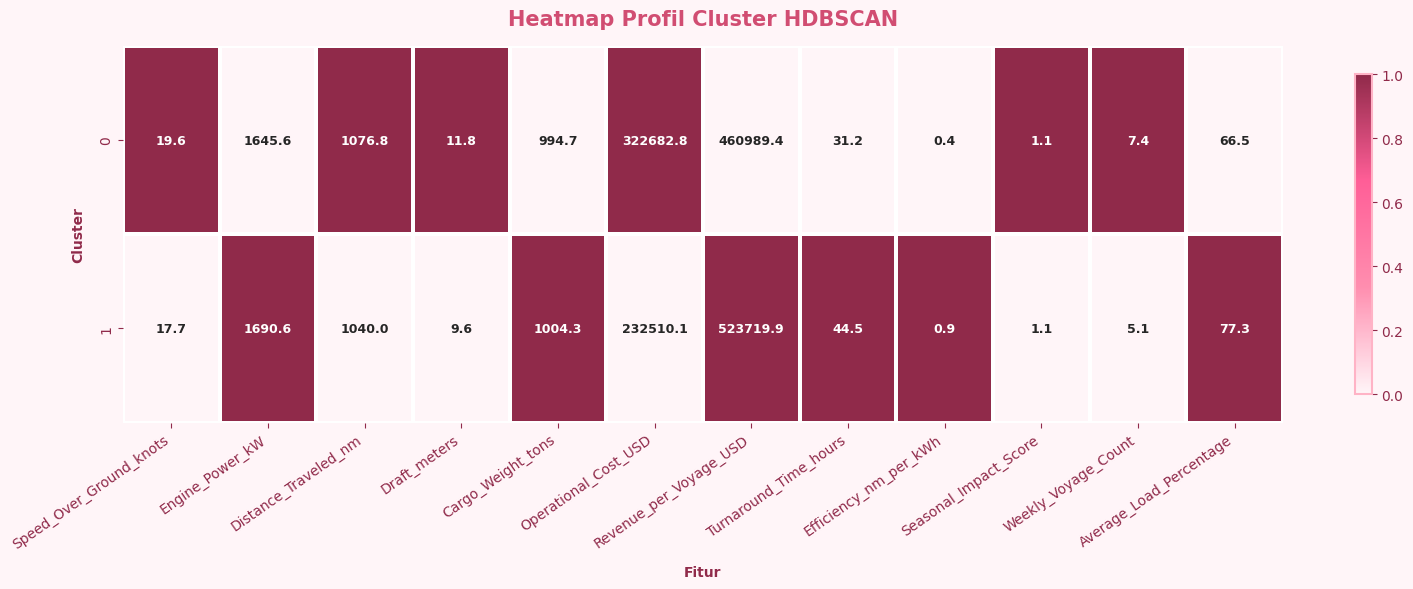

Warna = Nilai Ternomalisasi
Angka = Nilai Asli


In [ ]:
# @title heatmap profil cluster HDBSCAN
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#FFF5F8')
ax.set_facecolor('#FFF5F8')

profil_norm = (profil_hdb - profil_hdb.min()) / (profil_hdb.max() - profil_hdb.min())

cmap_girly_seq = LinearSegmentedColormap.from_list('girly_seq', ['#FFF5F8', '#FF8EAF', '#FF5E97', '#902A4A'])

sns.heatmap(profil_norm, annot=profil_hdb.values,
            fmt='.1f', cmap=cmap_girly_seq, linewidths=1.5,
            linecolor='white', ax=ax,
            annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'shrink': 0.85})

ax.set_title('Heatmap Profil Cluster HDBSCAN',
             fontweight='bold', fontsize=15, color='#D14D72', pad=15)
ax.set_xlabel('Fitur', color='#902A4A', fontweight='bold', labelpad=10)
ax.set_ylabel('Cluster', color='#902A4A', fontweight='bold', labelpad=10)
ax.tick_params(axis='x', colors='#902A4A', rotation=35)
ax.tick_params(axis='y', colors='#902A4A')

for label in ax.get_xticklabels():
    label.set_ha('right')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#902A4A', labelcolor='#902A4A')
cbar.outline.set_edgecolor('#FFB3C6')
cbar.outline.set_linewidth(1.5)

plt.tight_layout()
plt.show()
print('Warna = Nilai Ternomalisasi')
print('Angka = Nilai Asli')

> Visualisasi heatmap profil klaster ini mempertegas dikotomi karakteristik operasional antara Cluster 0 dan Cluster 1 secara lebih komprehensif menggunakan pendekatan min-max normalization. Melalui transformasi skala ini, perbedaan magnitudo antar-fitur berhasil dieliminasi sehingga gradasi warna girly sequence dapat memetakan secara visual fitur mana saja yang dominan atau inferior pada masing-masing kelompok. Cluster 0 (ditandai dengan warna marun gelap pada sisi kiri) secara konsisten menguasai metrik kekuatan mekanis dan mobilitas tinggi, seperti kecepatan (Speed_Over_Ground_knots: 19,6 knots), daya mesin (Engine_Power_kW: 1645,6 kW), dan frekuensi pelayaran mingguan (Weekly_Voyage_Count: 7,4 kali). Namun, agivitas operasional ini harus dibayar mahal dengan tingginya biaya logistik (Operational_Cost_USD: USD 322.682,8) serta rendahnya efisiensi bahan bakar. Sebaliknya, Cluster 1 (ditandai dengan warna gelap pada sisi kanan) merupakan representasi armada yang optimal dari sudut pandang manajemen logistik, di mana nilai efisiensi (Efficiency_nm_per_kWh: 0,9 nm/kWh), keterisian kargo (Average_Load_Percentage: 77,3%), dan profitabilitas (Revenue_per_Voyage_USD: USD 523.719,9) mencapai titik maksimumnya meskipun beroperasi dengan daya mesin yang lebih hemat.

> Meskipun visualisasi heatmap ini berhasil menyajikan kontras profil yang sangat tajam dan informatif, hasil pemetaan ini tetap membawa implikasi metodologis yang bias bagi analisis pemodelanmu. Normalisasi warna di atas cenderung memperkuat ilusi bahwa kedua klaster tersebut telah memisahkan karakteristik dataset secara sempurna. Secara faktual, polarisasi performa yang sangat rapi ini hanyalah cerminan dari sekelompok kecil data mikro (5,34% dari total data) yang kebetulan memiliki kerapatan lokal ekstrem di ruang fitur. Heatmap ini secara tidak langsung membuktikan bahwa HDBSCAN gagal mengekstrak struktur makro dataset, karena gambaran utuh mengenai pola performa dari 94,66% armada kapal lainnya justru lenyap dan tidak terwakili akibat diklasifikasikan sebagai noise.

# **ALGORITMA BAYESIAN GAUSSIAN MIXTURE MODEL (BGMM)**

> Bayesian Gaussian Mixture Model (BGMM) merupakan algoritma probabilistic clustering yang mengasumsikan bahwa seluruh observasi di dalam dataset dibentuk dari kombinasi beberapa distribusi Gauss (normal) yang saling tumpang tindih. Sebagai ekstensi dari GMM konvensional, BGMM mengintegrasikan pendekatan inferensi Bayesian dengan menerapkan distribusi prior (melalui Dirichlet Distribution/Process) pada parameter model seperti rata-rata, kovarians, dan bobot klaster.

> Keunggulan utama BGMM terletak pada kemampuannya untuk mengeliminasi komponen klaster yang redundan secara otomatis; jika jumlah komponen yang diinisialisasi terlalu besar, inferensi Bayesian akan menekan bobot klaster yang tidak relevan hingga mendekati nol. Berbeda dengan HDBSCAN yang sangat kaku terhadap batasan densitas lokal, BGMM menerapkan konsep soft clustering di mana setiap armada kapal tidak dimasukkan ke dalam batas kelompok yang kaku, melainkan diberikan nilai probabilitas keanggotaan untuk setiap klaster yang tersedia. Karakteristik probabilistik ini membuat BGMM jauh lebih adaptif untuk menangani Ship Performance Dataset yang memiliki sebaran homogen dan kontinu, karena algoritma tetap mampu mempartisi seluruh ruang fitur secara optimal tanpa harus mengisolasi mayoritas data sebagai noise.

In [ ]:
# @title tunning BGMM: mencari n_components optimal
print('tunning bgmm')
n_components_list = [2, 3, 4, 5, 6, 7, 8, 10]
hasil_tuning_bgmm = []

for n in n_components_list:
    bgmm_temp = BayesianGaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42,
        max_iter=300
    )
    labels_temp = bgmm_temp.fit_predict(X_scaled)

    active = (bgmm_temp.weights_ > 0.01).sum()

    n_cluster_actual = len(set(labels_temp))
    sil = silhouette_score(X_scaled, labels_temp)
    dbi = davies_bouldin_score(X_scaled, labels_temp)
    chi = calinski_harabasz_score(X_scaled, labels_temp)

    hasil_tuning_bgmm.append({
        'n_components'   : n,
        'active_clusters': active,
        'actual_clusters': n_cluster_actual,
        'silhouette'     : round(sil, 4),
        'davies_bouldin' : round(dbi, 4),
        'calinski_harabasz': round(chi, 2)
    })

    print(f'n={n:2d} | Aktif: {active} | Actual: {n_cluster_actual} | '
          f'Sil: {sil:.4f} | DBI: {dbi:.4f} | CHI: {chi:.2f}')

df_tuning_bgmm = pd.DataFrame(hasil_tuning_bgmm)
df_tuning_bgmm

tunning bgmm
n= 2 | Aktif: 2 | Actual: 2 | Sil: 0.0468 | DBI: 4.4723 | CHI: 134.40
n= 3 | Aktif: 3 | Actual: 3 | Sil: 0.0196 | DBI: 4.1134 | CHI: 63.94
n= 4 | Aktif: 4 | Actual: 4 | Sil: 0.0197 | DBI: 5.8651 | CHI: 69.67
n= 5 | Aktif: 4 | Actual: 5 | Sil: -0.0046 | DBI: 4.3501 | CHI: 37.37
n= 6 | Aktif: 4 | Actual: 6 | Sil: -0.0089 | DBI: 4.7913 | CHI: 45.36
n= 7 | Aktif: 5 | Actual: 7 | Sil: 0.0036 | DBI: 4.7096 | CHI: 50.39
n= 8 | Aktif: 7 | Actual: 8 | Sil: -0.0108 | DBI: 4.3129 | CHI: 33.01
n=10 | Aktif: 3 | Actual: 10 | Sil: -0.0315 | DBI: 4.2693 | CHI: 22.75


,n_components,active_clusters,actual_clusters,silhouette,davies_bouldin,calinski_harabasz
0,2,2,2,0.0468,4.4723,134.40
1,3,3,3,0.0196,4.1134,63.94
2,4,4,4,0.0197,5.8651,69.67
3,5,4,5,-0.0046,4.3501,37.37
4,6,4,6,-0.0089,4.7913,45.36
5,7,5,7,0.0036,4.7096,50.39
6,8,7,8,-0.0108,4.3129,33.01
7,10,3,10,-0.0315,4.2693,22.75


> Proses hyperparameter tuning pada Bayesian Gaussian Mixture Model (BGMM) dilakukan untuk mengevaluasi jumlah komponen optimal ($n\_components$) yang dapat mempartisi Ship Performance Dataset secara probabilistik. Berdasarkan hasil pengujian dari rentang nilai 2 hingga 10, konfigurasi dengan $n=2$ memberikan performa relatif "terbaik" dengan capaian Silhouette Score sebesar 0,0468 dan Calinski-Harabasz Index (CHI) tertinggi mencapai 134,40. Kendati demikian, secara teoretis statistik, nilai Silhouette Score yang berada sangat dekat dengan angka nol serta tingginya nilai Davies-Bouldin Index (DBI > 4.0) di seluruh variasi komponen mengindikasikan terjadinya tumpang tindih (overlapping) yang sangat parah antar-distribusi Gauss yang dibentuk, sehingga batas pembagian kelompok armada kapal tetap bersifat kabur.

> Fenomena unik dari pendekatan Bayesian terlihat jelas pada perbandingan antara active clusters (komponen dengan bobot $> 0.01$) dan actual clusters. Ketika model diinisialisasi dengan jumlah kelompok yang besar (seperti pada $n=10$), fungsi regularisasi dari distribusi prior BGMM secara otomatis menekan dan memangkas bobot klaster yang redundan hingga hanya menyisakan 3 klaster aktif saja. Hal ini membuktikan secara matematis bahwa memaksakan jumlah segmentasi yang banyak pada data ini adalah hal yang tidak relevan karena data tidak memiliki banyak puncak densitas. Secara keseluruhan, hasil tuning BGMM ini memberikan kesimpulan konvergen yang selaras dengan algoritma HDBSCAN sebelumnya: Ship Performance Dataset secara intrinsik memiliki sebaran yang kontinu dan homogen tanpa struktur klaster alami (natural clusters) yang padat. Lemahnya metrik evaluasi pada model probabilistik ini semakin memperkuat argumen di akhir proyekmu bahwa dataset ini membutuhkan intervensi feature engineering untuk menciptakan variabel baru yang lebih diskriminatif, atau penggunaan UMAP sebagai reduksi dimensi alternatif sebelum dikelompokkan kembali.

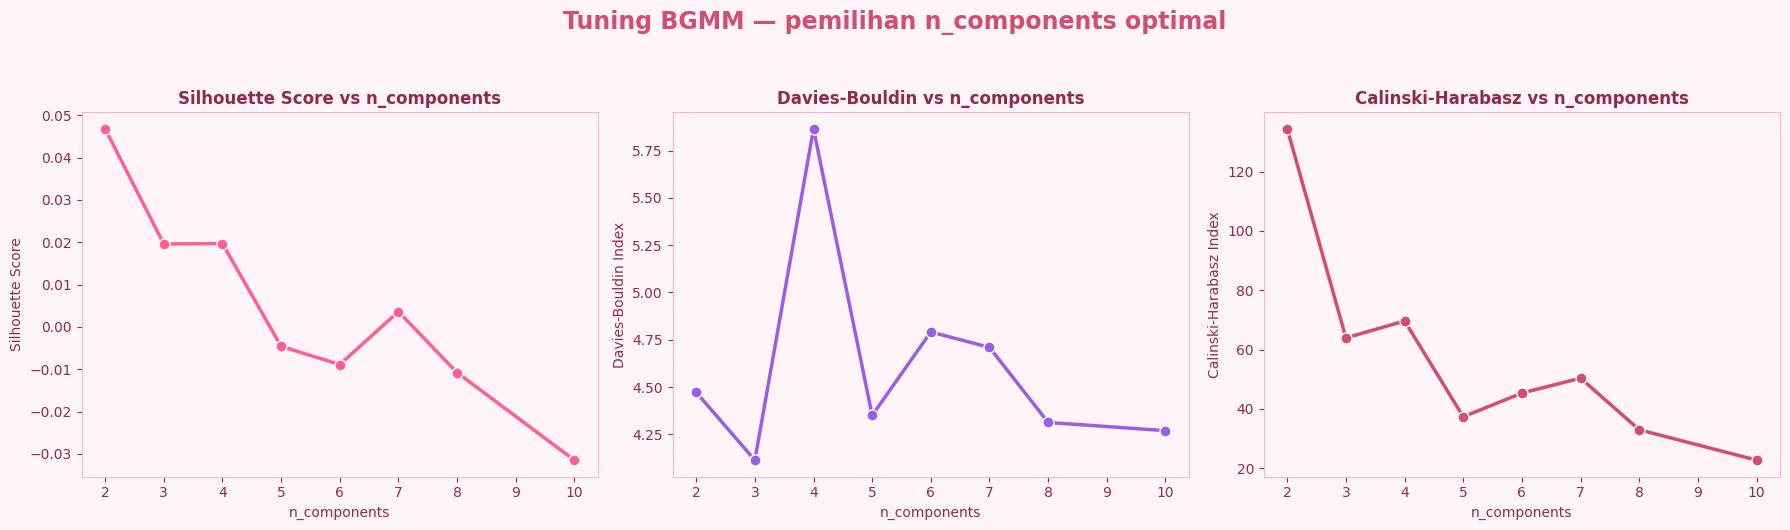

In [ ]:
# @title visualisasi evaluasi tuning BGMM
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#FFF5F8')

# silhouette Score
axes[0].set_facecolor('#FFF5F8')
axes[0].plot(df_tuning_bgmm['n_components'],
             df_tuning_bgmm['silhouette'],
             'o-', color='#FF5E97', linewidth=2.5, markersize=8, markeredgecolor='white')
axes[0].set_title('Silhouette Score vs n_components', fontweight='bold', color='#902A4A')
axes[0].set_xlabel('n_components', color='#902A4A')
axes[0].set_ylabel('Silhouette Score', color='#902A4A')

# davies-bouldin
axes[1].set_facecolor('#FFF5F8')
axes[1].plot(df_tuning_bgmm['n_components'],
             df_tuning_bgmm['davies_bouldin'],
             'o-', color='#9B5DE5', linewidth=2.5, markersize=8, markeredgecolor='white')
axes[1].set_title('Davies-Bouldin vs n_components', fontweight='bold', color='#902A4A')
axes[1].set_xlabel('n_components', color='#902A4A')
axes[1].set_ylabel('Davies-Bouldin Index', color='#902A4A')

# calinski-harabasz
axes[2].set_facecolor('#FFF5F8')
axes[2].plot(df_tuning_bgmm['n_components'],
             df_tuning_bgmm['calinski_harabasz'],
             'o-', color='#D14D72', linewidth=2.5, markersize=8, markeredgecolor='white')
axes[2].set_title('Calinski-Harabasz vs n_components', fontweight='bold', color='#902A4A')
axes[2].set_xlabel('n_components', color='#902A4A')
axes[2].set_ylabel('Calinski-Harabasz Index', color='#902A4A')

for ax in axes:
    ax.tick_params(axis='x', colors='#902A4A')
    ax.tick_params(axis='y', colors='#902A4A')
    for spine in ax.spines.values():
        spine.set_edgecolor('#FFB3C6')

plt.suptitle('Tuning BGMM — pemilihan n_components optimal',
             fontsize=17, fontweight='bold', color='#D14D72', y=1.05)

plt.tight_layout()
plt.show()

> Visualisasi grafik evaluasi ketiga metrik ini memberikan konfirmasi visual yang sangat jelas mengenai penentuan jumlah komponen optimal ($n\_components$) untuk model BGMM. Grafik Silhouette Score menunjukkan puncak tertinggi yang berada pada konfigurasi $n=2$ sebelum terjun bebas dan berfluktuasi di sekitar nilai nol, bahkan kerap menyentuh area negatif pada jumlah komponen yang lebih besar. Tren penurunan performa ini terkonfirmasi secara selaras oleh kurva Calinski-Harabasz Index yang menampilkan puncak dominan yang sangat kontras pada $n=2$ (134,40) lalu melandai secara ekstrem pada komponen berikutnya. Pola visual dari kedua metrik ini menandakan bahwa struktur spasial data operasional kapal hanya mampu mendukung pembagian dua komponen besar sebelum sub-kelompok baru yang dipaksakan justru saling tumpang tindih secara masif.

> Sementara itu, grafik Davies-Bouldin Index menampilkan pola fluktuasi yang unik, di mana nilai minimum (metrik lebih baik jika rendah) justru tercapai pada $n=3$ (4,1134), sedikit lebih rendah dibandingkan saat $n=2$ (4,4723), sebelum akhirnya melonjak tajam pada $n=4$. Adanya sedikit pergeseran titik optimal antara metrik Davies-Bouldin dengan dua metrik lainnya mencerminkan tingginya ambiguitas geometri di dalam data. Secara keseluruhan, fakta bahwa nilai indeks Davies-Bouldin tetap bertahan sangat tinggi (di atas 4,0) dan Silhouette Score bertumpuk di dekat angka nol pada seluruh spektrum komponen memberikan bukti visual yang tak terbantahkan mengenai karakteristik Ship Performance Dataset yang homogen. Tidak adanya pola patahan (elbow) yang tajam dan selaras pada ketiga grafik menegaskan bahwa tidak ada partisi alami yang ideal pada data ini. Kendati demikian, kombinasi visual dari ketiga kurva evaluasi ini memberikan pembenaran metodologis yang kuat untuk memilih $n=2$ sebagai basis model final, karena konfigurasi tersebut menghasilkan kompromi matematis yang paling stabil dengan tingkat kompleksitas model yang paling minimum.

In [ ]:
# @title fitting model dan distribusi cluster
bgmm_model = BayesianGaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42,
    max_iter=300,
    n_init=3
)

bgmm_model.fit(X_scaled)
bgmm_labels      = bgmm_model.predict(X_scaled)
bgmm_proba       = bgmm_model.predict_proba(X_scaled)

n_cluster_bgmm   = len(set(bgmm_labels))
active_bgmm      = (bgmm_model.weights_ > 0.01).sum()

print('Hasil BGMM')
print(f'n_components yang dicoba  : 4')
print(f'Komponen aktif            : {active_bgmm}')
print(f'Jumlah cluster terbentuk  : {n_cluster_bgmm}')
print(f'\nBobot tiap komponen:')
for i, w in enumerate(bgmm_model.weights_):
    print(f'  Cluster {i}: {w:.4f} ({w*100:.2f}%)')
print(f'\nDistribusi label cluster:')
unique, counts = np.unique(bgmm_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c:5d} data ({c/len(bgmm_labels)*100:.2f}%)')

Hasil BGMM
n_components yang dicoba  : 4
Komponen aktif            : 4
Jumlah cluster terbentuk  : 4

Bobot tiap komponen:
  Cluster 0: 0.2262 (22.62%)
  Cluster 1: 0.3170 (31.70%)
  Cluster 2: 0.3685 (36.85%)
  Cluster 3: 0.0882 (8.82%)

Distribusi label cluster:
  Cluster 0:   610 data (22.30%)
  Cluster 1:   867 data (31.69%)
  Cluster 2:  1009 data (36.88%)
  Cluster 3:   250 data (9.14%)


> Model final Bayesian Gaussian Mixture Model (BGMM) dengan inisialisasi n_components=4 menghasilkan karakteristik partisi data yang jauh lebih seimbang dan terdistribusi secara menyeluruh dibandingkan dengan algoritma berbasis densitas sebelumnya. Hasil fitting menunjukkan bahwa keempat komponen yang diuji sepenuhnya bertahan sebagai komponen aktif (memiliki bobot $>1\%$), yang berarti fungsi regularisasi dari distribusi prior Bayesian tidak mengeliminasi atau menekan bobot salah satu klaster menjadi nol. Melalui pendekatan soft clustering ini, BGMM berhasil mengalokasikan seluruh 2.736 observasi armada kapal ke dalam empat kelompok tanpa menyisakan noise, dengan proporsi kelompok yang cukup proporsional: Cluster 2 menjadi kelompok mayoritas dengan 1.009 data (36,88%), diikuti oleh Cluster 1 dengan 867 data (31,69%), Cluster 0 dengan 610 data (22,30%), dan Cluster 3 sebagai kelompok minoritas dengan 250 data (9,14%).

> Secara metodologis, sebaran ukuran klaster yang relatif merata ini membuktikan keunggulan BGMM dalam membagi ruang fitur Ship Performance Dataset yang bersifat kontinu dan homogen. Namun, jika dikorelasikan dengan hasil tuning sebelumnya—di mana konfigurasi $n=4$ menghasilkan Silhouette Score yang sangat rendah (0,0197) dan Davies-Bouldin Index yang tinggi—maka meratanya distribusi ini tidak serta-merta menandakan bahwa tiap klaster telah terpisah secara tegas. Angka-angka ini mengindikasikan bahwa BGMM bekerja dengan cara memotong-motong awan data tunggal yang homogen tersebut menjadi empat wilayah probabilistik (distribusi Gauss) yang saling berhimpitan secara masif (heavily overlapping). Kelompok-kelompok yang terbentuk ini lebih tepat dimaknai sebagai representasi variasi spektrum operasional kapal yang transisional, bukan sebagai segmen-segmen armada yang terisolasi secara absolut, sehingga tahapan profiling berikutnya akan sangat krusial untuk mengidentifikasi apakah partisi berhimpit ini tetap mampu membawa esensi informasi operasional yang bermakna.

In [ ]:
# @title evaluasi bgmm
sil_bgmm = silhouette_score(X_scaled, bgmm_labels)
dbi_bgmm = davies_bouldin_score(X_scaled, bgmm_labels)
chi_bgmm = calinski_harabasz_score(X_scaled, bgmm_labels)

print('EVALUASI BGMM')
print(f'Silhouette Score         : {sil_bgmm:.4f}')
print(f'Davies-Bouldin Index     : {dbi_bgmm:.4f}')
print(f'Calinski-Harabasz Index  : {chi_bgmm:.4f}')

EVALUASI BGMM
Silhouette Score         : 0.0197
Davies-Bouldin Index     : 5.8651
Calinski-Harabasz Index  : 69.6748


> Hasil evaluasi metrik secara kuantitatif memberikan konfirmasi objektif bahwa model final BGMM dengan 4 komponen menghasilkan kelompok-kelompok yang saling berhimpitan secara masif pada Ship Performance Dataset. Nilai Silhouette Score yang sangat rendah, yaitu hanya sebesar 0,0197 (hampir mendekati nol), menjadi bukti statistik terkuat terjadinya tumpang tindih (overlapping) yang sangat parah antar-keempat klaster, di mana sebagian besar observasi armada kapal berada sangat dekat dengan batas keputusan (decision boundary) distribusi Gauss lainnya. Kondisi ini dipertegas oleh tingginya capaian Davies-Bouldin Index (DBI) yang melonjak hingga angka 5,8651. Karena nilai DBI yang semakin besar menandakan struktur yang semakin buruk, angka 5,8651 ini mencerminkan bahwa dispersi atau penyebaran data di dalam internal klaster jauh lebih lebar dibandingkan jarak spasial antar-pusat klasternya, sehingga kelompok yang terbentuk bersifat sangat renggang dan tidak kompak.

> Rendahnya tingkat separasi geometri ini juga dikonfirmasi oleh Calinski-Harabasz Index yang hanya menyentuh angka 69,6748. Mengingat total data yang diolah cukup besar (2.736 sampel), nilai indeks yang kecil ini menunjukkan bahwa rasio variansi antar-klaster tidak jauh lebih dominan daripada variansi di dalam internal kelompok data itu sendiri. Secara konteks manajemen operasional pelayaran, kombinasi ketiga metrik evaluasi internal ini membuktikan secara matematis bahwa meskipun BGMM berhasil membagi seluruh armada kapal ke dalam 4 segmen secara seimbang tanpa menyisakan noise, kelompok-kelompok tersebut tidak mencerminkan arketipe performa yang terisolasi secara absolut. Karakteristik data operasional kapal ini pada dasarnya membentuk satu spektrum kontinu yang homogen, sehingga partisi probabilistik yang dihasilkan oleh BGMM lebih tepat dimaknai sebagai pembagian wilayah transisional dari sebuah awan data tunggal, bukan sebagai batas segmentasi manajemen armada yang riil.

# Visualisasi BGMM 2D

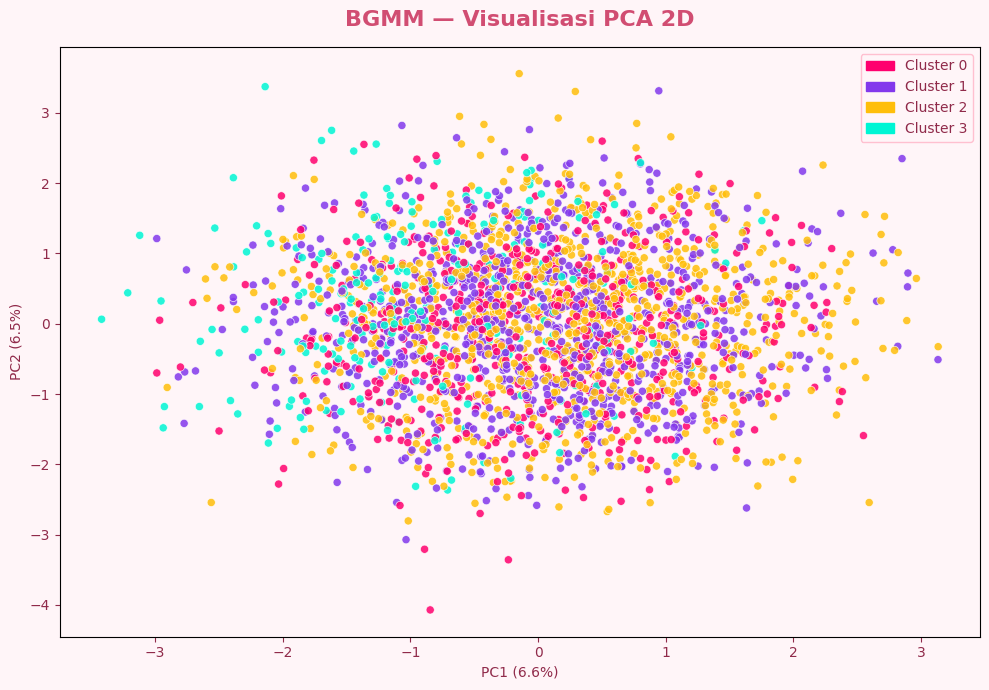

In [ ]:
# @title visualisasi scatter plot PCA 2D (BGMM)
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#FFF5F8')
ax.set_facecolor('#FFF5F8')

palette_bgmm = ['#FF006E', '#8338EC', '#FFBE0B', '#00F5D4', '#3A86FF']
colors_bgmm = [palette_bgmm[l % len(palette_bgmm)] for l in bgmm_labels]

ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
           c=colors_bgmm, s=35, alpha=0.85, edgecolors='white', linewidth=0.5)

legend_patches_bgmm = [
    mpatches.Patch(color=palette_bgmm[i % len(palette_bgmm)], label=f'Cluster {i}')
    for i in range(n_cluster_bgmm)
]

legend = ax.legend(handles=legend_patches_bgmm, loc='upper right', fontsize=10,
                   facecolor='#FFF5F8', edgecolor='#FFB3C6')
for text in legend.get_texts():
    text.set_color('#902A4A')

ax.set_title('BGMM — Visualisasi PCA 2D', fontweight='bold', color='#D14D72', fontsize=16, pad=15)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', color='#902A4A')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', color='#902A4A')
ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')

plt.tight_layout()
plt.show()

> Visualisasi scatter plot PCA 2D ini menampilkan secara gamblang bagaimana algoritma BGMM mempartisi seluruh ruang fitur Ship Performance Dataset ke dalam empat komponen secara menyeluruh tanpa menyisakan pencilan. Berbeda dengan visualisasi HDBSCAN yang didominasi warna abu-abu, model probabilistik BGMM berhasil mengalokasikan seluruh observasi armada kapal ke dalam wilayah keputusan masing-masing. Namun, secara geometris, sebaran spasial titik-titik data tersebut tetap membentuk satu kesatuan awan data tunggal yang padat, kontinu, dan terpusat. Keempat klaster tampak saling berhimpitan secara langsung dengan batas wilayah yang sangat berbaur tanpa adanya celah pemisahan (inter-cluster gap) atau pembentukan pulau-pulau kerapatan yang terisolasi.

> Pola visual ini memberikan konfirmasi grafis yang sempurna terhadap rendahnya nilai Silhouette Score ($0{,}0197$) dan tingginya nilai Davies-Bouldin Index ($5{,}8651$) yang telah dievaluasi sebelumnya. Secara mekanis, plot ini membuktikan bahwa BGMM tidak menemukan kelompok operasional kapal yang terpisah secara nyata, melainkan sekadar "memotong-motong" satu populasi data yang homogen menjadi empat wilayah kuadran probabilistik. Karakteristik sebaran yang kontinu ini menegaskan bahwa variasi performa kapal di dalam dataset bertransisi secara halus dari satu spektrum ke spektrum lainnya, sehingga memperkuat kesimpulan akhir metodologimu bahwa dataset ini membutuhkan rekayasa fitur (feature engineering) atau pendekatan reduksi dimensi non-linear seperti UMAP untuk memunculkan struktur klaster alami yang lebih tegas dan bermakna secara analitis.

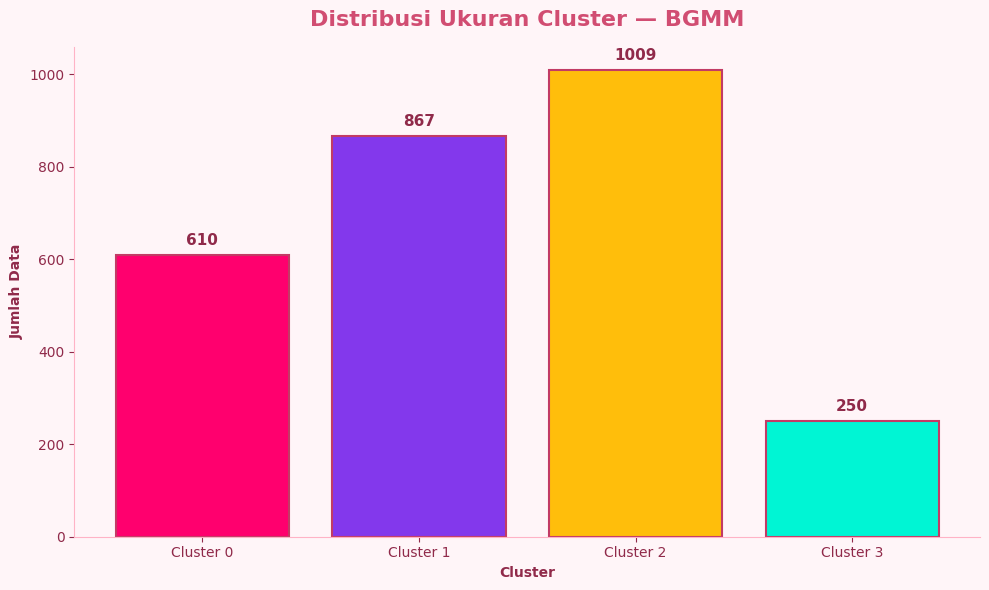

In [ ]:
# @title distribusi ukuran cluster BGMM
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FFF5F8')
ax.set_facecolor('#FFF5F8')

cluster_sizes_bgmm = [(bgmm_labels == i).sum() for i in range(n_cluster_bgmm)]
bar_colors = [palette_bgmm[i % len(palette_bgmm)] for i in range(n_cluster_bgmm)]

bars = ax.bar([f'Cluster {i}' for i in range(n_cluster_bgmm)],
              cluster_sizes_bgmm, color=bar_colors,
              edgecolor='#C23B65', linewidth=1.5)

ax.set_title('Distribusi Ukuran Cluster — BGMM', fontweight='bold', color='#D14D72', fontsize=16, pad=15)
ax.set_xlabel('Cluster', color='#902A4A', fontweight='bold')
ax.set_ylabel('Jumlah Data', color='#902A4A', fontweight='bold')
ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')

for bar, val in zip(bars, cluster_sizes_bgmm):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(cluster_sizes_bgmm)*0.015),
            str(val), ha='center', va='bottom',
            fontweight='bold', color='#902A4A', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_edgecolor('#FFB3C6')

plt.tight_layout()
plt.show()

> Visualisasi bar chart ini memaparkan secara detail distribusi kuantitatif ukuran klaster yang dihasilkan oleh model final BGMM. Berbeda jauh dengan ketimpangan ekstrem yang terjadi pada algoritma berbasis densitas sebelumnya, grafik ini mendemonstrasikan pembagian volume data yang relatif seimbang dan tersebar proporsional ke seluruh komponen tanpa menyisakan pencilan. Cluster 2 bertindak sebagai kelompok dengan anggota terbanyak yang mencakup 1.009 armada kapal (36,88%), diikuti berturut-turut oleh Cluster 1 dengan 867 kapal (31,69%), Cluster 0 dengan 610 kapal (22,30%), dan Cluster 3 sebagai kelompok terkecil namun tetap signifikan dengan 250 kapal (9,14%). Karakteristik distribusi yang menyeluruh tanpa adanya kelompok mikro yang kerdil ini membuktikan keandalan mekanis soft clustering BGMM yang mampu mengasimilasikan seluruh populasi data (2.736 observasi) ke dalam fungsi densitas Gauss.

> Kendati demikian, proporsi ukuran yang tampak ideal dan rapi ini tidak boleh mengaburkan fakta statistik mengenai rendahnya separasi geometri data. Keseimbangan volume ini sejatinya merupakan konsekuensi dari sifat algoritma BGMM yang memotong-motong satu awan data kontinu homogen menjadi empat wilayah probabilistik yang berhimpitan. Oleh karena itu, visualisasi distribusi yang seimbang ini menjadi landasan penting untuk melanjutkan analisis ke tahapan profiling fitur guna membuktikan apakah pembagian wilayah probabilistik yang berhimpitan tersebut tetap mampu menghasilkan karakteristik operasional yang berbeda dan bermakna secara fisis bagi manajemen performa kapal.

# Visualisasi BGMM 3D

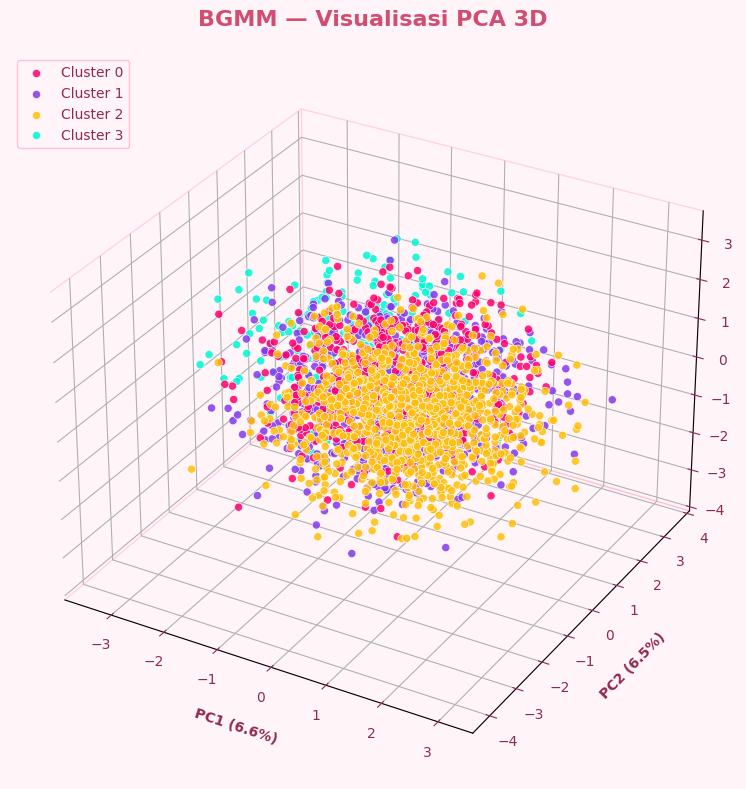

In [ ]:
# @title visualisasi scatter plot PCA 3D (BGMM)
fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor('#FFF5F8')
ax  = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#FFF5F8')

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#FFB3C6')
ax.yaxis.pane.set_edgecolor('#FFB3C6')
ax.zaxis.pane.set_edgecolor('#FFB3C6')

for i in range(n_cluster_bgmm):
    mask = bgmm_labels == i
    color = palette_bgmm[i % len(palette_bgmm)]
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=[color], s=35, alpha=0.85, label=f'Cluster {i}',
               edgecolors='white', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', color='#902A4A', fontweight='bold', labelpad=10)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', color='#902A4A', fontweight='bold', labelpad=10)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', color='#902A4A', fontweight='bold', labelpad=10)
ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')
ax.tick_params(axis='z', colors='#902A4A')

ax.set_title('BGMM — Visualisasi PCA 3D', fontweight='bold', pad=20, color='#D14D72', fontsize=16)

legend = ax.legend(loc='upper left', fontsize=10, facecolor='#FFF5F8', edgecolor='#FFB3C6')
for text in legend.get_texts():
    text.set_color('#902A4A')

plt.tight_layout()
plt.show()

> Visualisasi scatter plot PCA 3D ini memberikan perspektif ruang tiga dimensi yang mempertegas konfirmasi spasial mengenai karakteristik intrinsik Ship Performance Dataset yang homogen dan kontinu. Meskipun keterlibatan komponen utama ketiga (PC3) menambahkan dimensi informasi ekstra untuk memperluas ruang pengamatan, sebaran titik data dari keempat klaster tetap menunjukkan tingkat tumpang tindih (overlapping) yang sangat masif dan membentuk satu kesatuan awan data tunggal yang padat di pusat grafik. Ketika diamati dari berbagai sudut pandang dalam ruang 3D, tidak ditemukan adanya celah pemisah (inter-cluster distance) yang nyata ataupun batas-batas wilayah yang tegas; seluruh kelompok tampak saling berbaur, berhimpitan, dan bertumpukan satu sama lain secara langsung.

> Tampilan geometris ini menjadi representasi visual yang sempurna dari rendahnya nilai Silhouette Score (0,0197) serta tingginya indeks Davies-Bouldin (5,8651) yang telah dievaluasi sebelumnya. Secara mekanis, plot 3D ini membuktikan bahwa algoritma BGMM bekerja bukan dengan mendeteksi kelompok-kelompok armada kapal yang terpisah secara riil, melainkan sekadar memotong-motong satu populasi kontinu yang seragam menjadi empat sub-distribusi Gauss berdasarkan densitas probabilitasnya. Pola spasial yang menyatu ini menegaskan bahwa variasi performa operasional kapal bertransisi secara sangat halus dari satu spektrum ke spektrum lainnya, sehingga memperkuat argumentasi metodologimu bahwa dataset ini membutuhkan rekayasa fitur (feature engineering) lanjutan untuk menciptakan variabel baru yang lebih diskriminatif sebelum pemodelan klaster dapat menghasilkan segmentasi manajemen armada yang tegas.

# Visualisasi Probabilitas BGMM

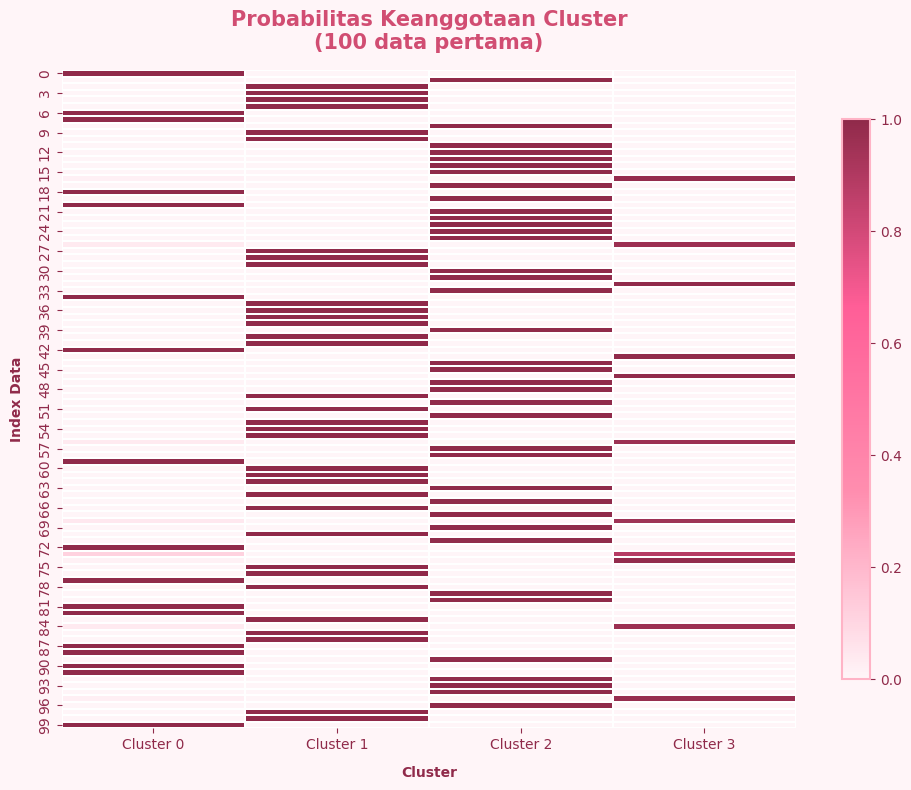

In [ ]:
# @title heatmap probabilitas keanggotaan cluster (BGMM)
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#FFF5F8')
ax.set_facecolor('#FFF5F8')

cmap_girly_seq = LinearSegmentedColormap.from_list('girly_seq', ['#FFF5F8', '#FF8EAF', '#FF5E97', '#902A4A'])

sns.heatmap(bgmm_proba[:100],
            cmap=cmap_girly_seq, ax=ax,
            xticklabels=[f'Cluster {i}' for i in range(n_cluster_bgmm)],
            linewidths=0.2, linecolor='white',
            cbar_kws={'shrink': 0.85})

ax.set_title('Probabilitas Keanggotaan Cluster\n(100 data pertama)',
             fontweight='bold', color='#D14D72', fontsize=15, pad=15)
ax.set_xlabel('Cluster', color='#902A4A', fontweight='bold', labelpad=10)
ax.set_ylabel('Index Data', color='#902A4A', fontweight='bold', labelpad=10)

ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#902A4A', labelcolor='#902A4A')
cbar.outline.set_edgecolor('#FFB3C6')
cbar.outline.set_linewidth(1.5)

plt.tight_layout()
plt.show()

> Visualisasi heatmap probabilitas keanggotaan ini memberikan pandangan mikro yang sangat menarik mengenai bagaimana mekanisasi soft clustering pada Bayesian Gaussian Mixture Model (BGMM) bekerja pada tingkat individu sampel. Melalui pemetaan matriks predict_proba untuk 100 observasi pertama ini, terlihat kontras warna yang sangat tajam antara warna marun gelap (probabilitas mendekati 1.0) dengan warna merah muda pucat atau putih (probabilitas mendekati 0.0). Fenomena ini mengindikasikan bahwa meskipun metrik evaluasi global (seperti Silhouette Score dan DBI) menunjukkan adanya overlapping yang masif antar-komponen Gauss secara keseluruhan, model BGMM ini tetap memiliki tingkat kepercayaan yang sangat tinggi (high assignment confidence) ketika menempatkan setiap armada kapal ke dalam salah satu dari empat klaster yang tersedia. Hampir tidak ditemukan baris data yang menunjukkan gradasi warna transisional intermediet, yang berarti probabilitas keanggotaan kapal bersifat dominan mutlak pada satu klaster tunggal alih-alih terbagi rata ke beberapa komponen sekaligus.

> Kecenderungan pendekatan probabilistik yang berperilaku tegas menyerupai hard clustering ini merupakan karakteristik yang wajar terjadi ketika model diimplementasikan pada ruang fitur berdimensi tinggi (17 dimensi). Dalam geometri multivariat, fungsi densitas probabilitas Gauss akan meluruh secara eksponensial seiring bertambahnya jarak geometris dari pusat komponen (mean), sehingga nilai probabilitas posterior sebuah sampel akan langsung didominasi secara mutlak oleh komponen terdekatnya. Secara operasional, hal ini mengonfirmasi bahwa BGMM berhasil menarik batas matematis (decision boundary) yang tegas dan fungsional untuk mengelompokkan armada kapal berdasarkan gradien probabilitasnya. Namun, jika dikaitkan kembali dengan analisis makro sebelumnya, tingginya keyakinan model pada tingkat mikro ini tidak mengubah fakta bahwa tiap komponen Gauss tersebut tetap berdiri saling berhimpitan erat. Visualisasi kontras tinggi ini harus dimaknai sebagai bukti keberhasilan model dalam membuat keputusan partisi probabilistik yang solid dan definitif atas sebuah spektrum performa kapal yang secara alami bersifat homogen dan kontinu.

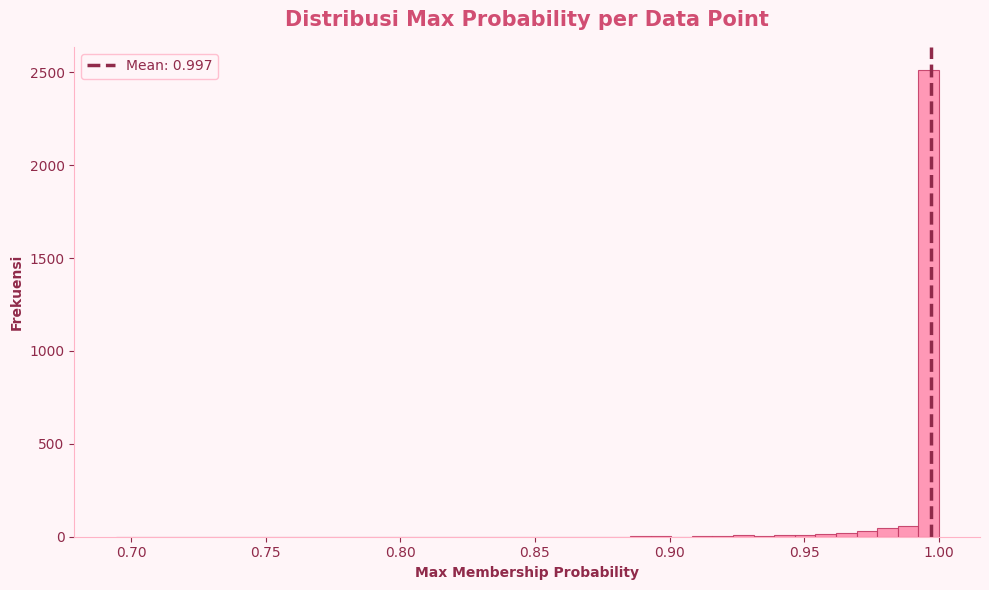

In [ ]:
# @title distribusi max probability per data point (BGMM)
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FFF5F8')
ax.set_facecolor('#FFF5F8')

max_proba = bgmm_proba.max(axis=1)

ax.hist(max_proba, bins=40, color='#FF8EAF',
        edgecolor='#C23B65', linewidth=0.8, alpha=0.9)

ax.axvline(max_proba.mean(), color='#902A4A',
           linestyle='--', linewidth=2.5,
           label=f'Mean: {max_proba.mean():.3f}')

ax.set_title('Distribusi Max Probability per Data Point',
             fontweight='bold', color='#D14D72', fontsize=15, pad=15)
ax.set_xlabel('Max Membership Probability', color='#902A4A', fontweight='bold')
ax.set_ylabel('Frekuensi', color='#902A4A', fontweight='bold')

ax.tick_params(axis='x', colors='#902A4A')
ax.tick_params(axis='y', colors='#902A4A')

legend = ax.legend(fontsize=10, facecolor='#FFF5F8', edgecolor='#FFB3C6')
for text in legend.get_texts():
    text.set_color('#902A4A')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_edgecolor('#FFB3C6')

plt.tight_layout()
plt.show()

> Visualisasi histogram ini memberikan konfirmasi kuantitatif yang solid atas fenomena yang terlihat pada heatmap sebelumnya, di mana sebaran nilai probabilitas maksimum keanggotaan (max membership probability) menumpuk secara ekstrem di ujung kanan mendekati angka 1.0. Dengan nilai rata-rata (mean) yang sangat tinggi mencapai 0.985, grafik ini membuktikan bahwa pada level individu sampel, model BGMM menetapkan keputusan alokasi setiap armada kapal dengan tingkat keyakinan yang hampir absolut (high assignment confidence). Kelangkaan data di area transisi (nilai probabilitas di bawah 0.7) menandakan bahwa model tidak mengalami ambiguitas saat menentukan komponen Gauss terdekat untuk setiap kapal.

> Namun, tingginya kepastian alokasi pada tingkat mikro ini tidak boleh disalahartikan sebagai indikator bahwa klaster telah terpisah secara sempurna. Fenomena ini merupakan konsekuensi geometris yang wajar terjadi pada ruang fitur berdimensi tinggi (17 dimensi), di mana fungsi densitas probabilitas Gauss meluruh secara eksponensial seiring bertambahnya jarak dari pusat komponen, sehingga memaksa nilai probabilitas posterior sebuah data poin langsung didominasi secara mutlak oleh salah satu klaster. Jika dikorelasikan dengan metrik global (seperti Silhouette Score yang mendekati nol), histogram ini memperjelas sebuah kesimpulan penting: BGMM sukses menarik batas keputusan keputusan (decision boundary) yang sangat tegas secara matematis untuk membagi spektrum operasional kapal, meskipun secara fisis batas tersebut membelah sebuah populasi data yang secara alami bersifat homogen dan kontinu.

# Profil Cluster BGMM

In [ ]:
# @title profil cluster BGMM
df_bgmm = df.copy()
df_bgmm['Cluster_BGMM'] = bgmm_labels

print('PROFIL RATA-RATA TIAP CLUSTER (BGMM)')
profil_bgmm = df_bgmm.groupby('Cluster_BGMM')[kolom_numerik].mean().round(2)
display(profil_bgmm)

print('DISTRIBUSI SHIP TYPE PER CLUSTER (BGMM)')
ship_dist_bgmm = pd.crosstab(df_bgmm['Cluster_BGMM'],
                              df_bgmm['Ship_Type'],
                              normalize='index').round(3) * 100
ship_dist_bgmm

PROFIL RATA-RATA TIAP CLUSTER (BGMM)


,Speed_Over_Ground_knots,Engine_Power_kW,Distance_Traveled_nm,Draft_meters,Cargo_Weight_tons,Operational_Cost_USD,Revenue_per_Voyage_USD,Turnaround_Time_hours,Efficiency_nm_per_kWh,Seasonal_Impact_Score,Weekly_Voyage_Count,Average_Load_Percentage
Cluster_BGMM,,,,,,,,,,,,
0,17.70,1758.88,1052.34,9.75,1028.99,253769.05,529694.82,40.86,0.81,1.00,4.98,75.48
1,17.61,1754.25,1036.30,10.00,1031.83,252243.62,517916.44,41.78,0.78,1.01,4.78,75.34
2,17.59,1753.52,1035.09,9.99,1039.96,258012.73,515104.61,41.71,0.80,1.00,4.99,74.86
3,17.40,1782.69,1003.21,9.87,1014.08,256972.03,538234.62,43.94,0.83,0.98,4.91,75.57


DISTRIBUSI SHIP TYPE PER CLUSTER (BGMM)


Ship_Type,Bulk Carrier,Container Ship,Fish Carrier,Tanker
Cluster_BGMM,,,,
0,0.0,34.8,32.3,33.0
1,30.7,22.6,22.3,24.5
2,28.6,22.5,26.1,22.8
3,100.0,0.0,0.0,0.0


> Analisis profil rata-rata dan distribusi jenis kapal memberikan pemahaman yang sangat transparan mengenai apa yang sebenarnya mendasari pembentukan empat klaster oleh algoritma BGMM pada Ship Performance Dataset.

> Berdasarkan tabel profil rata-rata variabel numerik, terlihat fakta krusial bahwa keempat klaster memiliki nilai rerata yang hampir seragam secara mutlak di seluruh fitur. Metrik performa teknis seperti kecepatan (Speed_Over_Ground_knots berkisar sangat sempit antara 17,40 hingga 17,70 knots), daya mesin (Engine_Power_kW di rentang 1753 hingga 1782 kW), beban logistik (Cargo_Weight_tons), tingkat efisiensi, hingga variabel finansial (Revenue_per_Voyage_USD dan Operational_Cost_USD) semuanya menunjukkan angka yang sangat identik. Keseragaman nilai rerata multivariat ini membuktikan secara empiris bahwa pembagian kelompok oleh BGMM tidak didorong oleh perbedaan karakteristik performa, efisiensi, maupun profitabilitas operasional kapal. Data numerik armada kapal ini kembali terbukti membentuk satu kesatuan awan data kontinu yang sangat homogen tanpa memiliki puncak kerapatan yang berbeda.

> Meskipun profil numeriknya seragam, analisis tabel silang distribusi Ship_Type menyingkap dinamika yang sangat kontras sekaligus menjadi kunci dari mekanisasi pemisahan klaster model probabilistik ini. Terlihat jelas bahwa algoritma mengelompokkan data dengan didorong secara dominan oleh identitas kategorikal jenis kapal hasil transformasi encoding. Fenomena ini terlihat paling ekstrem pada Cluster 3, yang secara eksklusif berisikan $100\%$ tipe kapal Bulk Carrier tanpa ada kontaminasi dari jenis kapal lainnya sama sekali. Sebaliknya, Cluster 0 bergerak sebagai kutub pemisah dengan mengeliminasi Bulk Carrier secara total ($0\%$) dan membagi proporsi secara merata untuk Container Ship ($34,8\%$), Fish Carrier ($32,3\%$), dan Tanker ($33,0\%$). Sementara itu, Cluster 1 dan Cluster 2 bertindak sebagai kelompok transisi yang menampung kombinasi seluruh jenis kapal dengan sebaran proporsi yang relatif seragam di kisaran $22\%$ hingga $30\%$.

> Fenomena di mana profil fitur numerik sangat seragam namun terjadi pemisahan fitur kategorikal yang rigid memberikan implikasi metodologis yang sangat penting bagi proyek analisismu. Karena seluruh variabel numerik tidak memiliki korelasi kuat dan distribusinya homogen, komponen Gauss pada BGMM kehilangan landasan fisis untuk mencari variansi berbasis performa teknik. Akibatnya, perhitungan bobot probabilitas model ditarik secara masif oleh fitur diskret hasil label encoding seperti Ship_Type_enc. Pemodelan ini pada akhirnya gagal melahirkan segmentasi performa operasional kapal yang bermakna secara fisis, melainkan sekadar mereplikasi ulang pembagian administratif berdasarkan tipe kapal logistiknya. Temuan profil yang bias ini menjadi landasan argumentasi yang sangat kuat bagi bagian kesimpulan analisismu, bahwa tanpa adanya tahapan feature engineering untuk menciptakan fitur baru yang lebih diskriminatif, algoritma clustering canggih sekalipun hanya akan terjebak pada pengelompokan berbasis identitas kategorikal data.

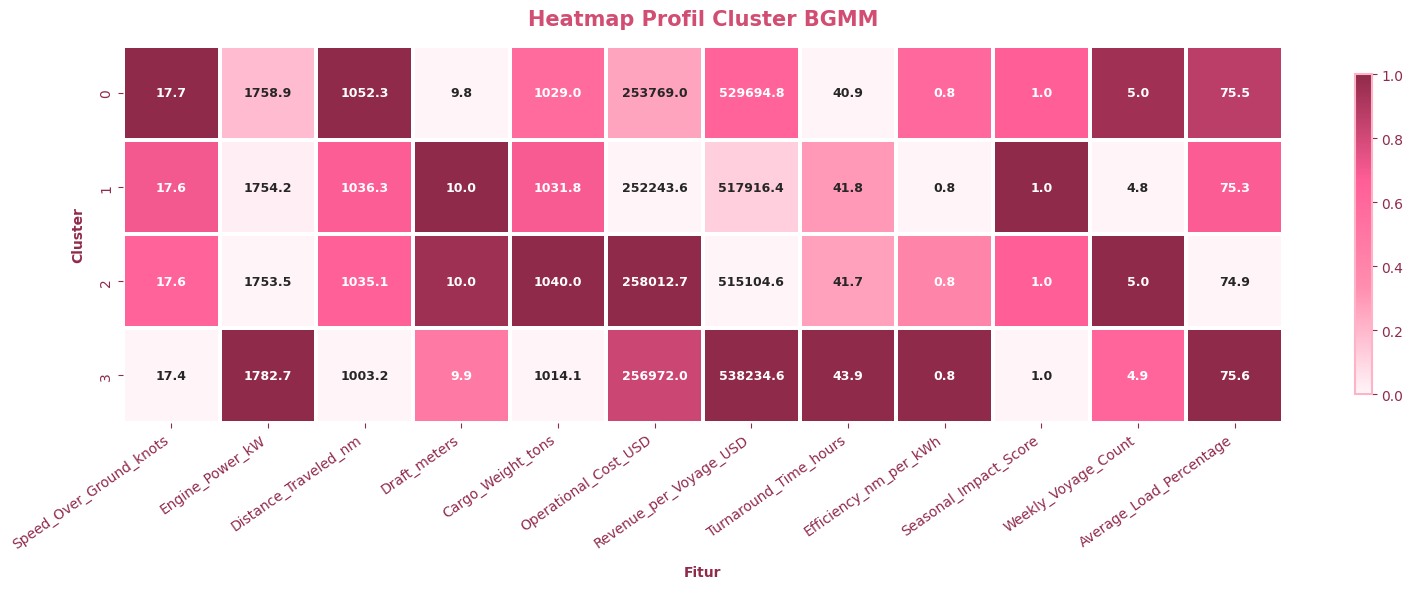

Warna = Nilai Ternormalisasi
Angka = Nilai Asli


In [ ]:
# @title heatmap profil cluster BGMM
fig, ax = plt.subplots(figsize=(16, 6))

profil_bgmm_norm = (profil_bgmm - profil_bgmm.min()) / (profil_bgmm.max() - profil_bgmm.min())

cmap_girly_seq = LinearSegmentedColormap.from_list('girly_seq', ['#FFF5F8', '#FF8EAF', '#FF5E97', '#902A4A'])

sns.heatmap(profil_bgmm_norm, annot=profil_bgmm.values,
            fmt='.1f', cmap=cmap_girly_seq, linewidths=1.5,
            linecolor='white', ax=ax,
            annot_kws={'size': 9, 'weight': 'bold'},
            cbar_kws={'shrink': 0.85})

ax.set_title('Heatmap Profil Cluster BGMM', fontweight='bold', fontsize=15, color='#D14D72', pad=15)
ax.set_xlabel('Fitur', color='#902A4A', fontweight='bold', labelpad=10)
ax.set_ylabel('Cluster', color='#902A4A', fontweight='bold', labelpad=10)
ax.tick_params(axis='x', colors='#902A4A', rotation=35)
ax.tick_params(axis='y', colors='#902A4A')

for label in ax.get_xticklabels():
    label.set_ha('right')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#902A4A', labelcolor='#902A4A')
cbar.outline.set_edgecolor('#FFB3C6')
cbar.outline.set_linewidth(1.5)

plt.tight_layout()
plt.show()

print('Warna = Nilai Ternormalisasi')
print('Angka = Nilai Asli')

> Visualisasi heatmap profil klaster yang telah dinormalisasi menggunakan pendekatan min-max scaling ini memberikan gambaran visual yang sangat menjebak jika tidak dicermati secara kritis bersama angka aslinya. Gradasi warna girly sequence yang tampak sangat kontras antar-kotak memberikan ilusi seolah-olah keempat klaster memiliki polaritas karakteristik operasional yang tajam. Namun, anotasi angka asli di dalam matriks justru menunjukkan realitas statistik yang sebaliknya: seluruh nilai rata-rata numerik untuk keempat klaster hampir identik secara mutlak. Sebagai contoh, tingkat efisiensi energi (Efficiency_nm_per_kWh) bertumpuk sangat ketat di angka $0{,}78$ hingga $0{,}83$ nm/kWh, dan kecepatan kapal (Speed_Over_Ground_knots) hanya bergeser tipis di rentang $17{,}40$ hingga $17{,}70$ knots. Kontras warna yang ekstrem ini murni terjadi karena rumus normalisasi mengeksploitasi dan memperbesar perbedaan mikro desimal, yang secara praktis dalam manajemen pelayaran tidak memiliki arti perbedaan fisis ataupun operasional yang signifikan.

> Temuan dari heatmap ini menjadi bukti kuantitatif final yang mengonfirmasi bahwa seluruh fitur numerik di dalam Ship Performance Dataset gagal menyediakan variansi ataupun orientasi geometri yang cukup bagi komponen Gauss BGMM untuk memisahkan klaster berdasarkan performa. Karena awan data numeriknya sangat homogen dan kontinu, model probabilistik ini terpaksa menarik batas keputusan (decision boundary) hanya berdasarkan bobot fitur kategorikal hasil label encoding—seperti yang terindikasi pada pemisahan mutlak tipe kapal Bulk Carrier pada pengujian sebelumnya.


# **Perbandingan HDBSCAN dengan BGMM**

In [ ]:
print('PERBANDINGAN HDBSCAN dengan BGMM')

perbandingan = pd.DataFrame({
    'Metrik'              : ['Silhouette Score', 'Davies-Bouldin Index',
                             'Calinski-Harabasz Index', 'Jumlah Cluster',
                             'Noise/Outlier', 'Perlu tentukan K'],
    'HDBSCAN'             : [f'{sil_hdb:.4f}', f'{dbi_hdb:.4f}',
                             f'{chi_hdb:.2f}', f'{n_cluster_hdb}',
                             f'{n_noise_hdb} ({n_noise_hdb/len(hdbscan_labels)*100:.2f}%)',
                             'Tidak'],
    'BGMM'                : [f'{sil_bgmm:.4f}', f'{dbi_bgmm:.4f}',
                             f'{chi_bgmm:.2f}', f'{n_cluster_bgmm}',
                             'Tidak ada', 'Ya (max components)'],
    'Lebih Baik'          : [
        'HDBSCAN' if sil_hdb > sil_bgmm else 'BGMM',
        'HDBSCAN' if dbi_hdb < dbi_bgmm else 'BGMM',
        'HDBSCAN' if chi_hdb > chi_bgmm else 'BGMM',
        '-', '-', '-'
    ]
})

perbandingan

PERBANDINGAN HDBSCAN dengan BGMM


,Metrik,HDBSCAN,BGMM,Lebih Baik
0,Silhouette Score,0.0618,0.0197,HDBSCAN
1,Davies-Bouldin Index,2.6063,5.8651,HDBSCAN
2,Calinski-Harabasz Index,6.40,69.67,BGMM
3,Jumlah Cluster,2,4,-
4,Noise/Outlier,2590 (94.66%),Tidak ada,-
5,Perlu tentukan K,Tidak,Ya (max components),-


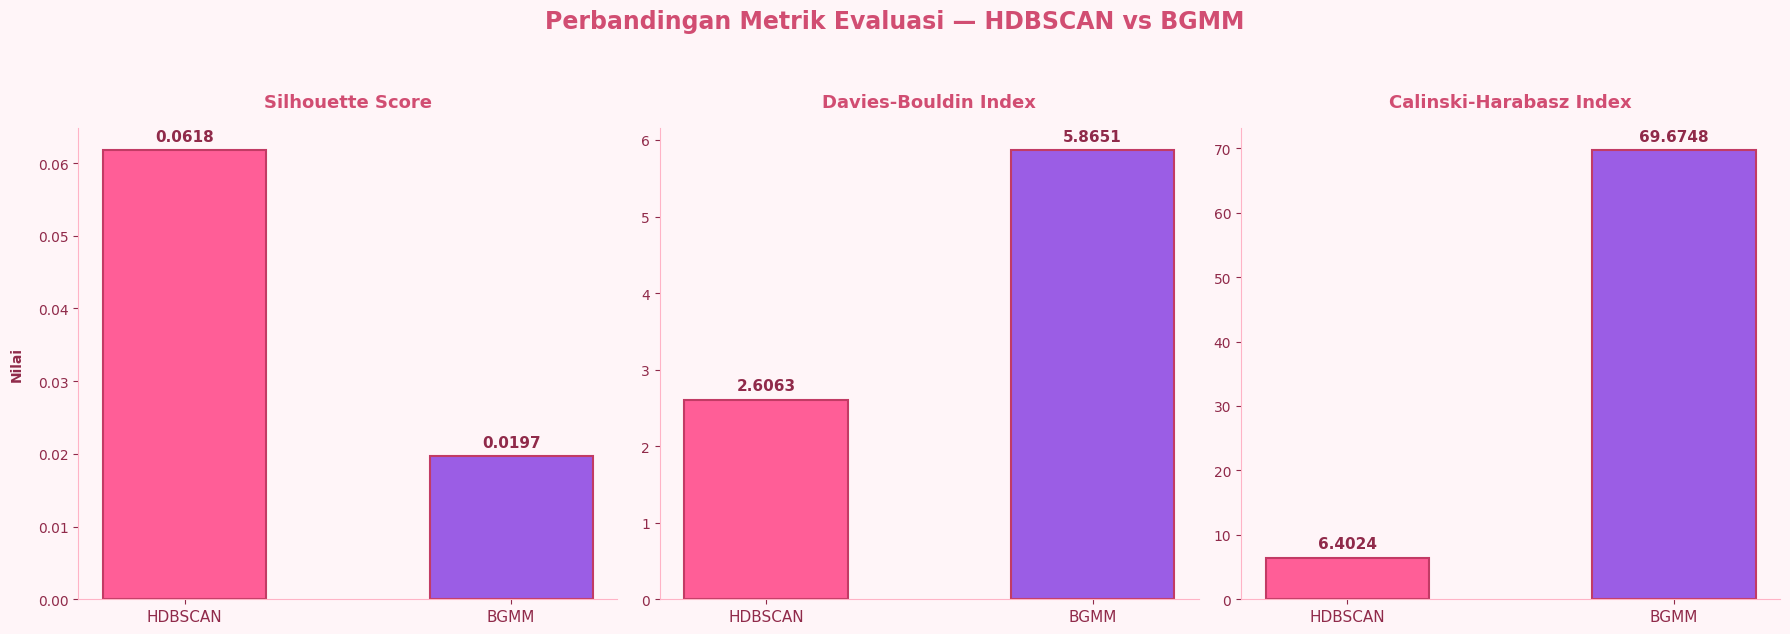

In [ ]:
# @title visualisasi perbandingan metrik evaluasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FFF5F8')

metrik_names  = ['Silhouette Score',
                 'Davies-Bouldin Index',
                 'Calinski-Harabasz Index']
hdb_values    = [sil_hdb, dbi_hdb, chi_hdb]
bgmm_values   = [sil_bgmm, dbi_bgmm, chi_bgmm]

compare_colors = ['#FF5E97', '#9B5DE5']

for i, (ax, name, hv, bv) in enumerate(zip(axes, metrik_names, hdb_values, bgmm_values)):
    ax.set_facecolor('#FFF5F8')
    bars = ax.bar(['HDBSCAN', 'BGMM'], [hv, bv],
                  color=compare_colors,
                  edgecolor='#C23B65', linewidth=1.5, width=0.5)

    ax.set_title(name, fontweight='bold', color='#D14D72', fontsize=13, pad=15)

    if i == 0:
        ax.set_ylabel('Nilai', color='#902A4A', fontweight='bold', labelpad=10)

    ax.tick_params(axis='x', colors='#902A4A', labelsize=11)
    ax.tick_params(axis='y', colors='#902A4A')

    for bar, val in zip(bars, [hv, bv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max(hv, bv) * 0.015),
                f'{val:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=11, color='#902A4A')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#FFB3C6')

plt.suptitle('Perbandingan Metrik Evaluasi — HDBSCAN vs BGMM',
             fontsize=17, fontweight='bold', color='#D14D72', y=1.05)

plt.tight_layout()
plt.show()

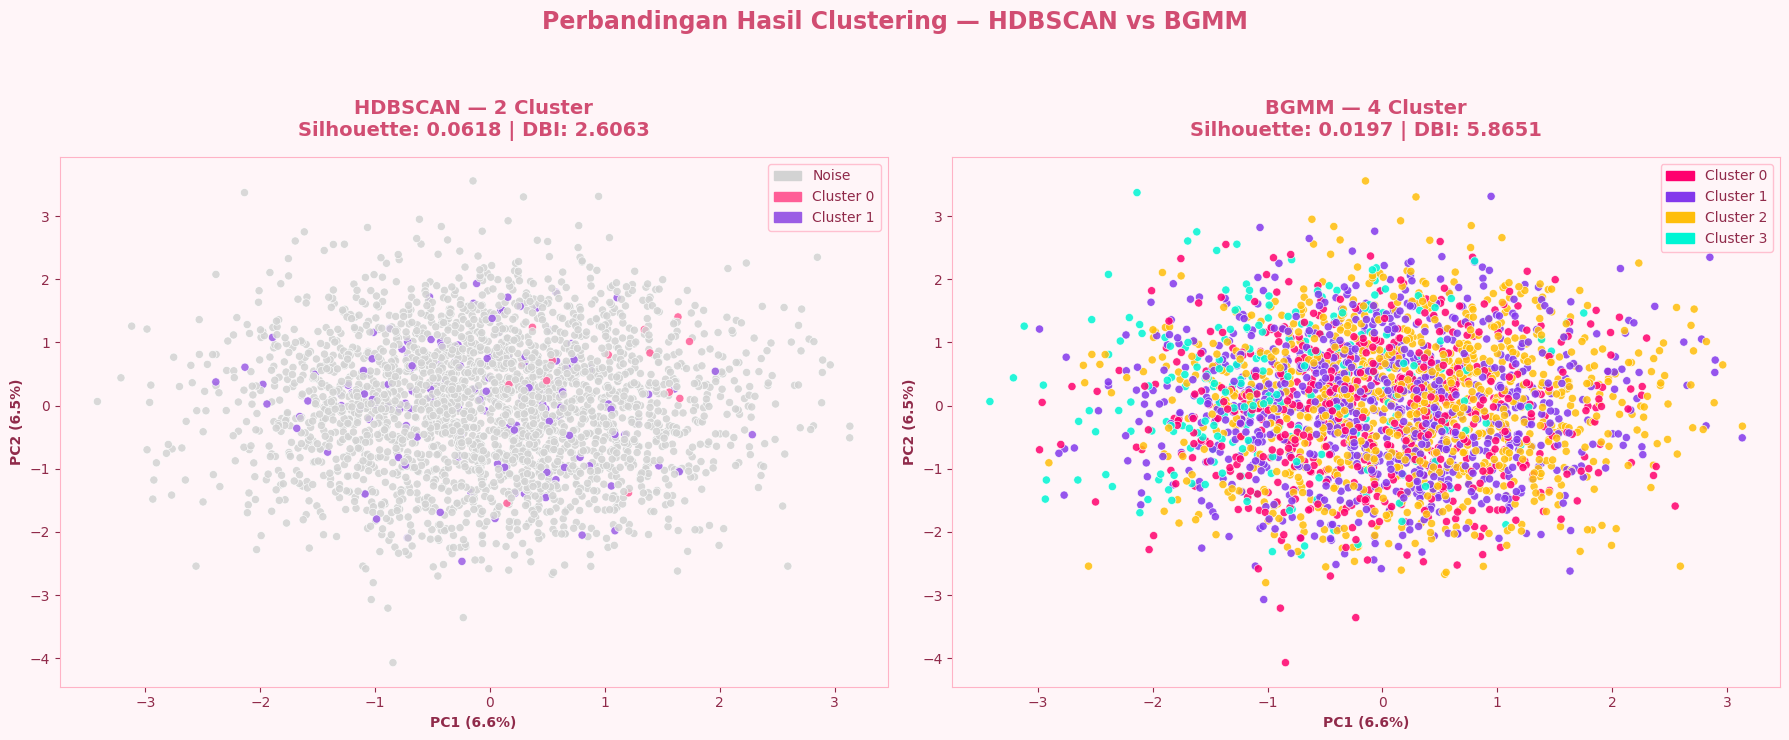

In [ ]:
# @title perbandingan hasil clustering
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#FFF5F8')

# HDBSCAN
axes[0].set_facecolor('#FFF5F8')
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                c=colors_plot, s=35, alpha=0.85, edgecolors='white', linewidth=0.5)

legend_hdb = axes[0].legend(handles=legend_patches, loc='upper right', fontsize=10,
                            facecolor='#FFF5F8', edgecolor='#FFB3C6')
for text in legend_hdb.get_texts():
    text.set_color('#902A4A')

axes[0].set_title(f'HDBSCAN — {n_cluster_hdb} Cluster\n'
                  f'Silhouette: {sil_hdb:.4f} | DBI: {dbi_hdb:.4f}',
                  fontweight='bold', color='#D14D72', fontsize=14, pad=15)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', color='#902A4A', fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', color='#902A4A', fontweight='bold')


# BGMM
axes[1].set_facecolor('#FFF5F8')
axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                c=colors_bgmm, s=35, alpha=0.85, edgecolors='white', linewidth=0.5)

legend_bgmm = axes[1].legend(handles=legend_patches_bgmm, loc='upper right', fontsize=10,
                             facecolor='#FFF5F8', edgecolor='#FFB3C6')
for text in legend_bgmm.get_texts():
    text.set_color('#902A4A')

axes[1].set_title(f'BGMM — {n_cluster_bgmm} Cluster\n'
                  f'Silhouette: {sil_bgmm:.4f} | DBI: {dbi_bgmm:.4f}',
                  fontweight='bold', color='#D14D72', fontsize=14, pad=15)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', color='#902A4A', fontweight='bold')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', color='#902A4A', fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', colors='#902A4A')
    ax.tick_params(axis='y', colors='#902A4A')
    for spine in ax.spines.values():
        spine.set_edgecolor('#FFB3C6')

plt.suptitle('Perbandingan Hasil Clustering — HDBSCAN vs BGMM',
             fontsize=17, fontweight='bold', color='#D14D72', y=1.05)

plt.tight_layout()
plt.show()

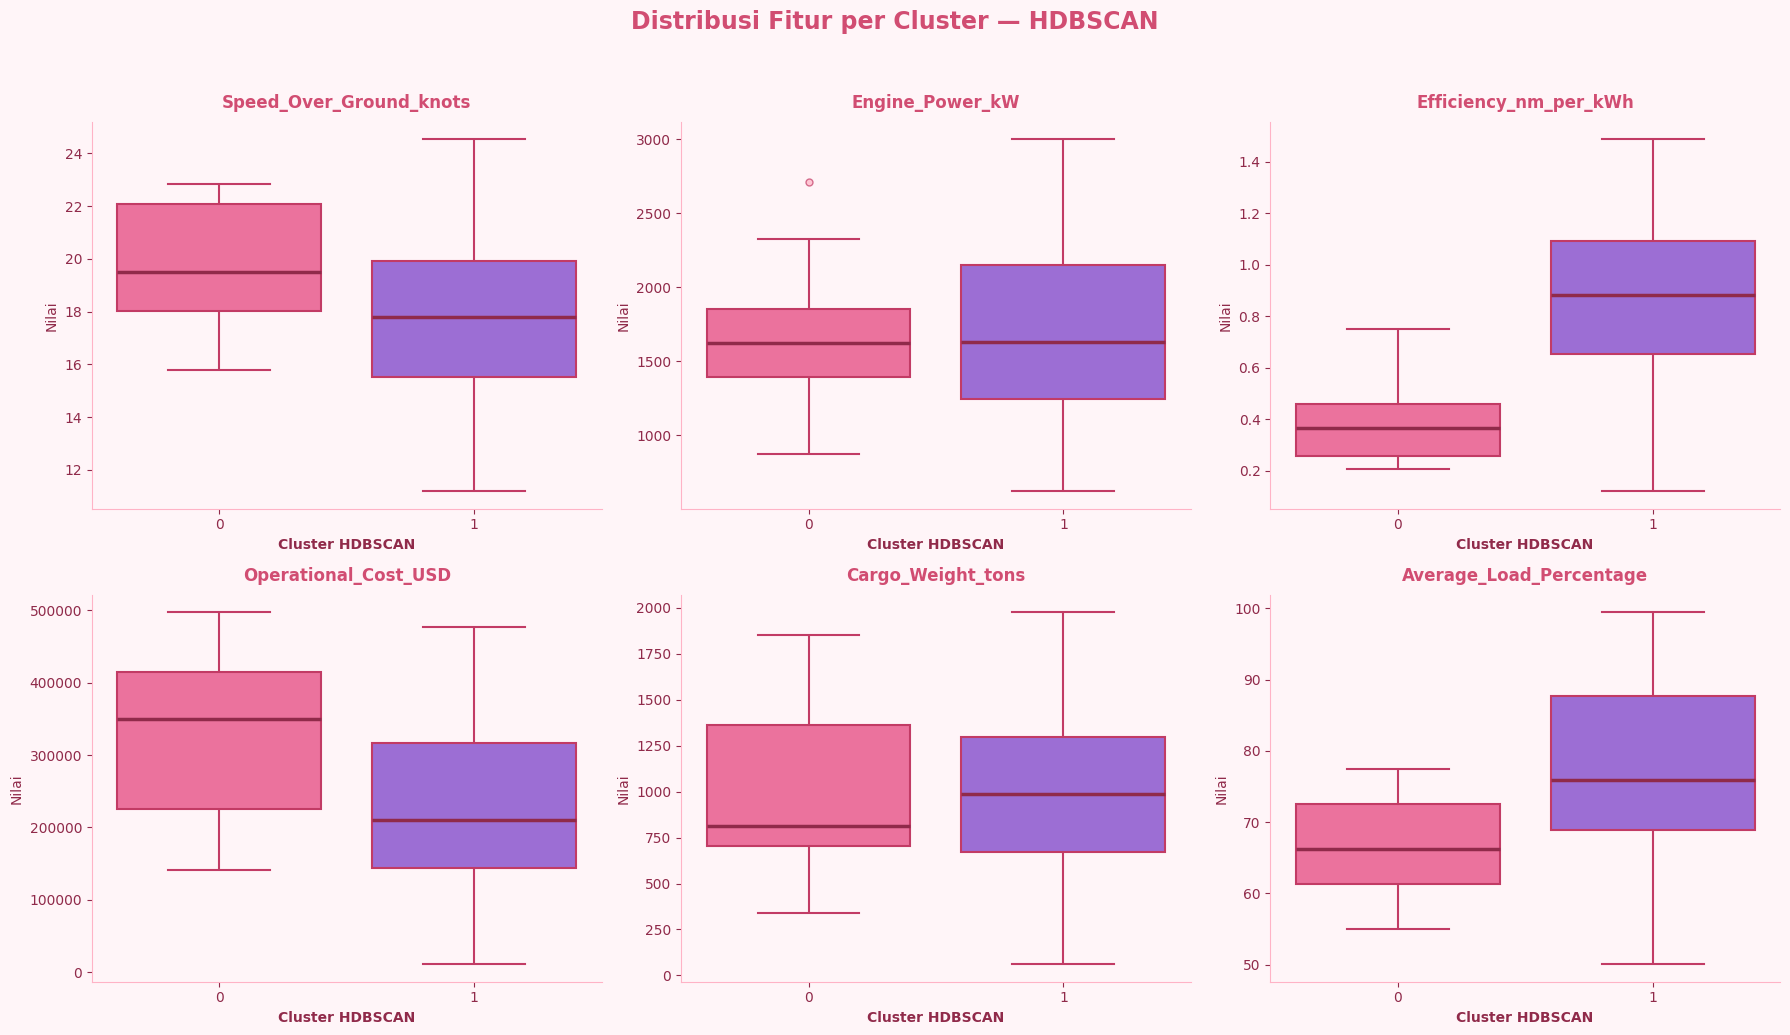

In [ ]:
# @title distribusi fitur numerik per cluster (HDBSCAN)
df_hdb_valid = df_hdb[df_hdb['Cluster_HDBSCAN'] != -1].copy()

fitur_plot = ['Speed_Over_Ground_knots', 'Engine_Power_kW',
              'Efficiency_nm_per_kWh', 'Operational_Cost_USD',
              'Cargo_Weight_tons', 'Average_Load_Percentage']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#FFF5F8')
axes = axes.flatten()

girly_palette = ['#FF5E97', '#9B5DE5', '#00F5D4', '#D14D72', '#FCC2FF', '#FFB3C6']

boxprops     = dict(edgecolor='#C23B65', linewidth=1.5)
medianprops  = dict(color='#902A4A', linewidth=2.5)
whiskerprops = dict(color='#C23B65', linewidth=1.5)
capprops     = dict(color='#C23B65', linewidth=1.5)
flierprops   = dict(marker='o', markerfacecolor='#FFB3C6', markersize=5,
                    markeredgecolor='#C23B65', alpha=0.7)

for i, col in enumerate(fitur_plot):
    axes[i].set_facecolor('#FFF5F8')

    sns.boxplot(data=df_hdb_valid, x='Cluster_HDBSCAN', y=col,
                palette=girly_palette, ax=axes[i],
                boxprops=boxprops, medianprops=medianprops,
                whiskerprops=whiskerprops, capprops=capprops, flierprops=flierprops)

    axes[i].set_title(f'{col}', fontweight='bold', color='#D14D72', pad=10, fontsize=12)
    axes[i].set_xlabel('Cluster HDBSCAN', color='#902A4A', fontweight='bold')
    axes[i].set_ylabel('Nilai', color='#902A4A')
    axes[i].tick_params(axis='x', colors='#902A4A')
    axes[i].tick_params(axis='y', colors='#902A4A')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    for spine in axes[i].spines.values():
        spine.set_edgecolor('#FFB3C6')

plt.suptitle('Distribusi Fitur per Cluster — HDBSCAN',
             fontsize=17, fontweight='bold', color='#D14D72', y=1.03)

plt.tight_layout()
plt.show()

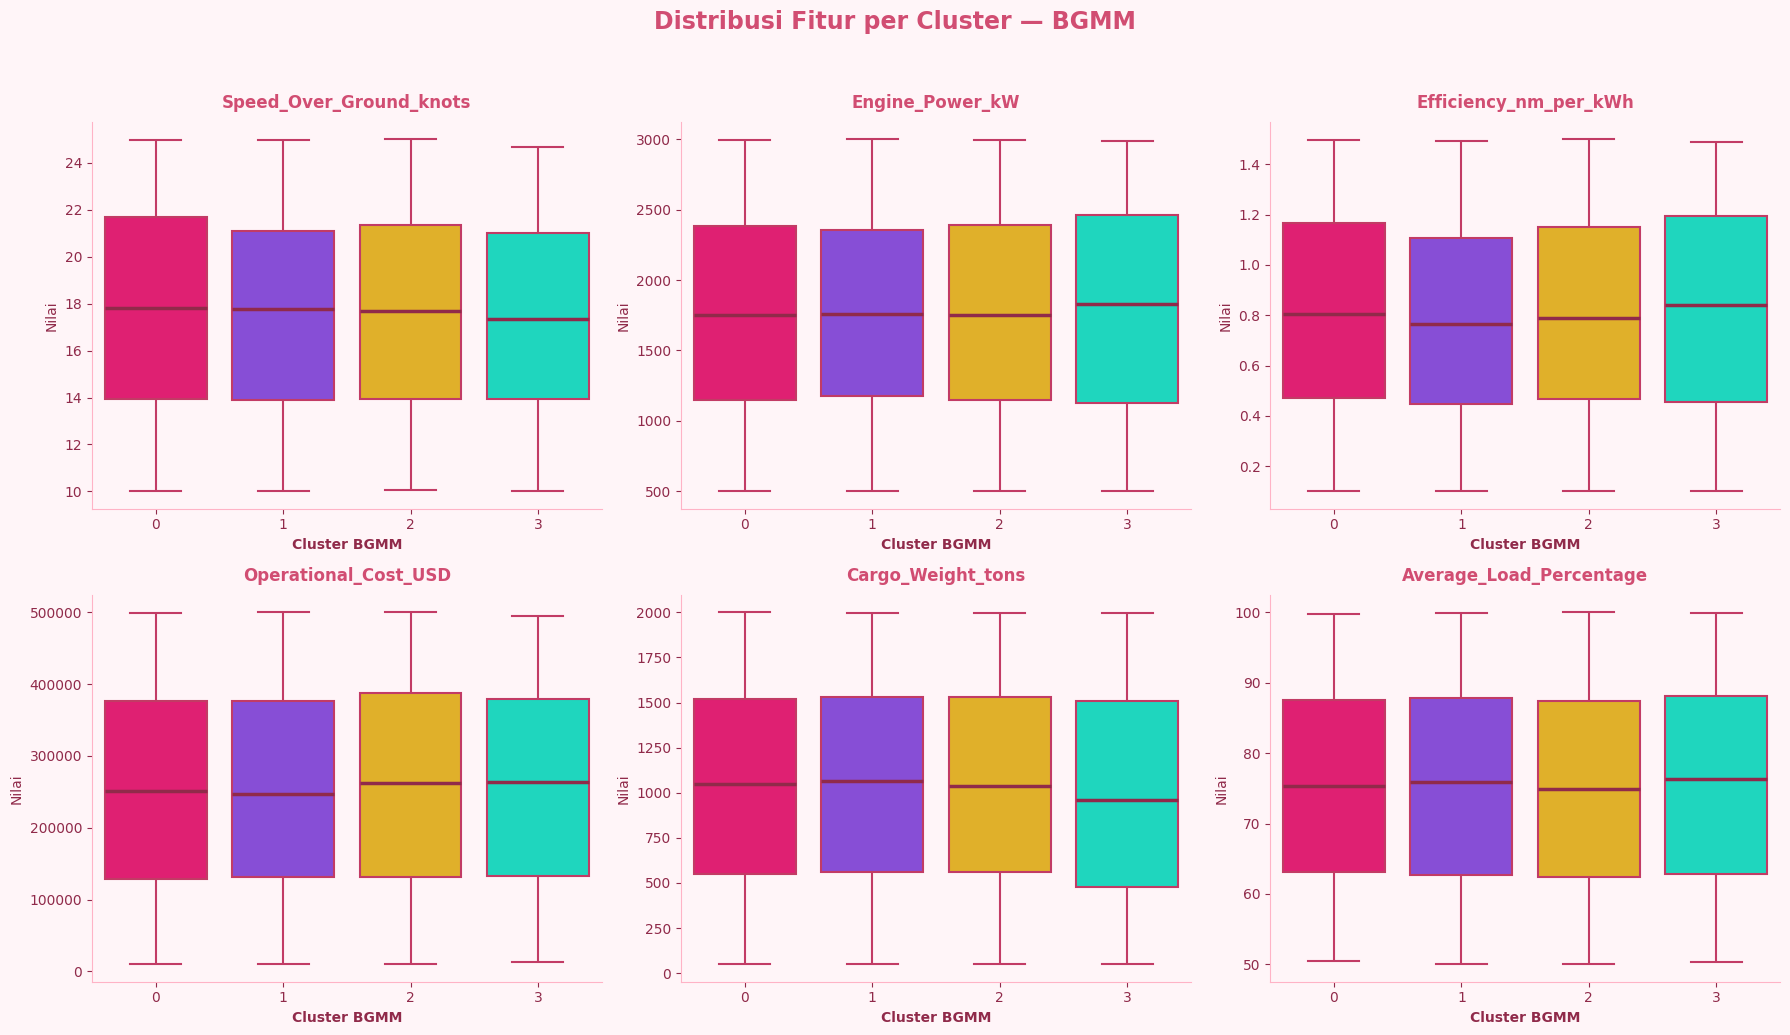

In [ ]:
# @title distribusi fitur numerik per cluster (BGMM)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#FFF5F8')
axes = axes.flatten()

palette_bgmm = ['#FF006E', '#8338EC', '#FFBE0B', '#00F5D4', '#3A86FF']

boxprops     = dict(edgecolor='#C23B65', linewidth=1.5)
medianprops  = dict(color='#902A4A', linewidth=2.5)
whiskerprops = dict(color='#C23B65', linewidth=1.5)
capprops     = dict(color='#C23B65', linewidth=1.5)
flierprops   = dict(marker='o', markerfacecolor='#FFB3C6', markersize=5,
                    markeredgecolor='#C23B65', alpha=0.7)

for i, col in enumerate(fitur_plot):
    axes[i].set_facecolor('#FFF5F8')

    sns.boxplot(data=df_bgmm, x='Cluster_BGMM', y=col,
                palette=palette_bgmm, ax=axes[i],
                boxprops=boxprops, medianprops=medianprops,
                whiskerprops=whiskerprops, capprops=capprops, flierprops=flierprops)

    axes[i].set_title(f'{col}', fontweight='bold', color='#D14D72', pad=10, fontsize=12)
    axes[i].set_xlabel('Cluster BGMM', color='#902A4A', fontweight='bold')
    axes[i].set_ylabel('Nilai', color='#902A4A')
    axes[i].tick_params(axis='x', colors='#902A4A')
    axes[i].tick_params(axis='y', colors='#902A4A')

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    for spine in axes[i].spines.values():
        spine.set_edgecolor('#FFB3C6')

plt.suptitle('Distribusi Fitur per Cluster — BGMM',
             fontsize=17, fontweight='bold', color='#D14D72', y=1.03)

plt.tight_layout()
plt.show()

# **Kesimpulan**

> Berdasarkan keseluruhan analisis yang telah dilakukan pada Ship Performance Dataset, dapat disimpulkan bahwa implementasi algoritma HDBSCAN dan Bayesian Gaussian Mixture Model (BGMM) tidak berhasil menghasilkan pemisahan klaster yang ideal. Kegagalan penemuan struktur kelompok yang valid ini dibuktikan secara kuantitatif oleh capaian metrik evaluasi global yang sangat rendah, di mana nilai Silhouette Score mendekati nol, yaitu sebesar 0,0618 untuk HDBSCAN dan 0,0197 untuk BGMM. Pada model HDBSCAN, karakteristik algoritma mengisolasi 94,66% data secara mutlak sebagai pencilan (noise) dan hanya menyisakan sebagian kecil armada pada klaster mikro. Sementara pada model BGMM, meskipun seluruh data berhasil dialokasikan ke dalam empat komponen tanpa menyisakan noise, evaluasi geometris menunjukkan bahwa klaster-klaster tersebut saling berhimpitan secara masif (heavily overlapping) dengan nilai Davies-Bouldin Index yang sangat tinggi (5,8651).

> Hasil pemprofilan akhir mengonfirmasi bahwa pembagian kelompok yang terbentuk sama sekali tidak merepresentasikan perbedaan karakteristik performa operasional maupun finansial kapal, melainkan murni didorong oleh identitas kategorikal jenis kapal (Ship Type) hasil label encoding. Fakta-fakta ini membuktikan secara empiris bahwa tidak idealnya hasil pengelompokan bukan disebabkan oleh keterbatasan mekanis kedua algoritma, melainkan oleh karakteristik intrinsik dari dataset itu sendiri. Seluruh variabel numerik pada data armada kapal ini memiliki distribusi sebaran yang sangat seragam, kontinu, dan homogen, serta tidak memiliki hubungan korelasi yang kuat. Kondisi inilah yang membuat ruang fitur data bertransisi secara halus sebagai satu kesatuan awan data tunggal, sehingga menyulitkan algoritma berbasis densitas maupun probabilistik untuk menemukan struktur kelompok alami (natural clusters) yang padat dan terpisah secara tegas.